# Tiền Xử Lý Văn Bản (Text Preprocessing)
### Dataset: IMDB 50K Movie Reviews
---
**Nội dung notebook:**
- **(a)** Pipeline chuẩn hóa văn bản
- **(b)** So sánh chiến lược tokenization
- **(c)** Loại bỏ stop words và phân tích thông tin
- **(d)** Stemming, Lemmatization và so sánh định lượng
- **(e)** Vector hóa văn bản và phân tích không gian đặc trưng
- **(f)** Biểu diễn ngữ nghĩa bằng Sentence Transformer


# 0. Cài đặt thư viện

In [1]:
import subprocess, sys

packages = [
    "nltk", "spacy", "gensim", "tokenizers",
    "sentence-transformers", "scikit-learn",
    "beautifulsoup4", "matplotlib", "seaborn",
    "pandas", "numpy", "tqdm"
]

for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)

# Tải spaCy model tiếng Anh
subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "--quiet"], check=False)
print("✅ Cài đặt hoàn tất!")


✅ Cài đặt hoàn tất!


# 1. Import thư viện

In [2]:
# ── Standard ──────────────────────────────────────────────────────────────────
import re, string, warnings, os
warnings.filterwarnings("ignore")

# ── Data ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from collections import Counter, defaultdict

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.titlesize": 13, "axes.labelsize": 11})
sns.set_theme(style="whitegrid", palette="Set2")

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk.tag import pos_tag

import spacy

from bs4 import BeautifulSoup

# ── Tokenizers (HuggingFace) ──────────────────────────────────────────────────
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# ── Gensim ────────────────────────────────────────────────────────────────────
from gensim.models import Word2Vec

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             silhouette_score)
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif

# ── Sentence Transformers ─────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer

# ── NLTK Downloads ────────────────────────────────────────────────────────────
for resource in ["punkt", "punkt_tab", "stopwords", "wordnet",
                 "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng",
                 "omw-1.4"]:
    nltk.download(resource, quiet=True)

print("✅ Import hoàn tất!")


✅ Import hoàn tất!


# 2. Load dữ liệu IMDB

In [3]:
# Load dữ liệu từ local path
df = pd.read_csv("../data/raw/IMDB Dataset.csv")

# Lấy tối thiểu 10.000 dòng (stratified để cân bằng nhãn)
N_SAMPLES = 50_000
df = (df.groupby("sentiment", group_keys=False)
        .apply(lambda x: x.sample(N_SAMPLES // 2, random_state=42))
        .reset_index(drop=True))

# Encode nhãn
le = LabelEncoder()
df["label"] = le.fit_transform(df["sentiment"])   # negative=0, positive=1

print(f"Shape       : {df.shape}")
print(f"Columns     : {df.columns.tolist()}")
print(f"Labels      : {df['sentiment'].value_counts().to_dict()}")
print(f"\nSample review (100 chars):")
print(df["review"].iloc[0][:200])


Shape       : (50000, 3)
Columns     : ['review', 'sentiment', 'label']
Labels      : {'negative': 25000, 'positive': 25000}

Sample review (100 chars):
I was looking forward to seeing Bruce Willis in this, especially since I remember being mesmerised by the original when I was young.<br /><br />This movie is a perfect example of how movie companies c


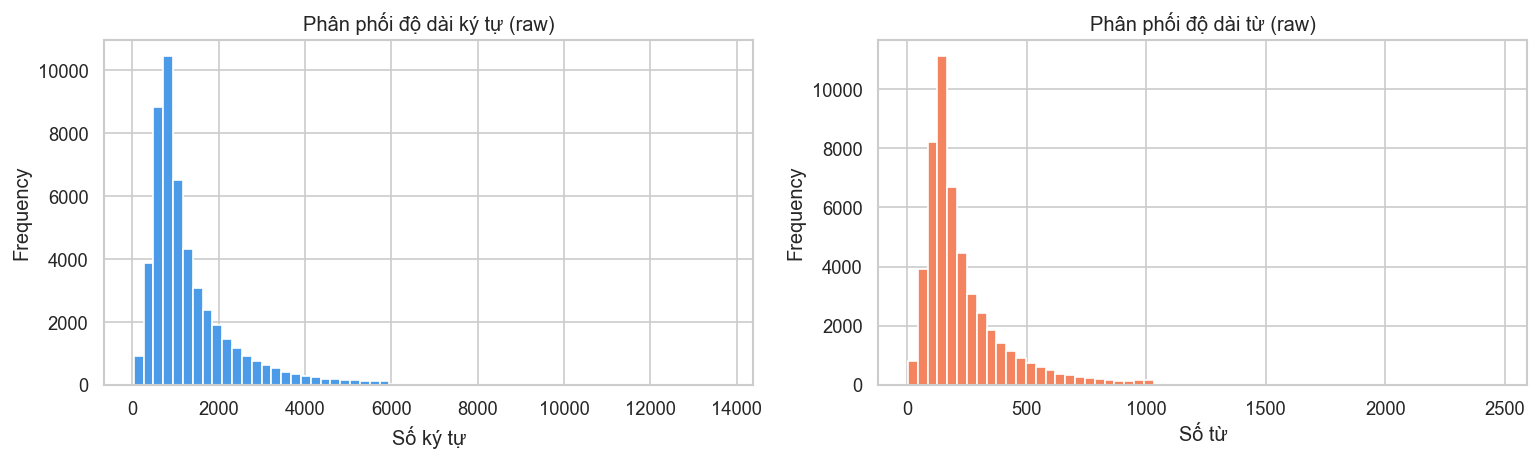

       char_len_raw  word_len_raw
count      50000.00      50000.00
mean        1309.43        231.16
std          989.73        171.34
min           32.00          4.00
25%          699.00        126.00
50%          970.00        173.00
75%         1590.25        280.00
max        13704.00       2470.00


In [4]:
# Thống kê cơ bản về độ dài văn bản (trước tiền xử lý)
df["char_len_raw"]  = df["review"].str.len()
df["word_len_raw"]  = df["review"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["char_len_raw"], bins=60, color="#4C9BE8", edgecolor="white")
axes[0].set_title("Phân phối độ dài ký tự (raw)")
axes[0].set_xlabel("Số ký tự")

axes[1].hist(df["word_len_raw"], bins=60, color="#F4845F", edgecolor="white")
axes[1].set_title("Phân phối độ dài từ (raw)")
axes[1].set_xlabel("Số từ")

for ax in axes:
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(df[["char_len_raw", "word_len_raw"]].describe().round(2))


## 📊 Phân tích & Nhận xét – Tiền xử lý văn bản

---

### 🗂️ Tổng quan tập dữ liệu

Tập dữ liệu **IMDB 50K Movie Reviews** là một trong những benchmark kinh điển trong lĩnh vực **Phân tích cảm xúc (Sentiment Analysis)** và **Khai phá văn bản (Text Mining)**. Tập dữ liệu bao gồm **50.000 bình luận phim** được thu thập từ trang web IMDb, với nhãn nhị phân `positive` / `negative` được phân bổ **cân bằng** (25.000 mỗi loại).

#### Đặc điểm nổi bật

| Thuộc tính | Giá trị |
|---|---|
| Tổng số mẫu | 50.000 reviews |
| Số lớp nhãn | 2 (`positive`, `negative`) |
| Phân bổ nhãn | Cân bằng (50% – 50%) |
| Ngôn ngữ | Tiếng Anh |
| Độ dài trung bình | ~1.309 ký tự / ~231 từ |

#### Phân phối độ dài văn bản (raw)

Nhìn vào biểu đồ phân phối **trước khi tiền xử lý**, có thể rút ra một số nhận xét sau:

- **Phân phối lệch phải (right-skewed):** Cả độ dài ký tự lẫn số từ đều có phân phối lệch phải rõ rệt — phần lớn các review có độ dài vừa phải, nhưng vẫn tồn tại một số lượng nhỏ review rất dài.
- **Độ dài ký tự:** Trung bình ~**1.309 ký tự**, trung vị ~**970 ký tự**; giá trị lớn nhất lên đến **13.704 ký tự**, cho thấy có những review cực kỳ chi tiết.
- **Độ dài từ:** Trung bình ~**231 từ**, trung vị ~**173 từ**; review dài nhất chứa đến **2.470 từ**.
- **Độ lệch chuẩn cao** (char: ~990, word: ~171) phản ánh sự **biến động lớn** về độ dài giữa các review — đây là điều cần lưu ý khi lựa chọn `max_length` cho mô hình.

> ⚠️ Sự chênh lệch đáng kể giữa **mean** và **median** (ký tự: 1309 vs 970; từ: 231 vs 173) là dấu hiệu rõ ràng của phân phối lệch, cần xem xét kỹ khi thiết lập ngưỡng cắt độ dài trong quá trình tiền xử lý.

# (a) Pipeline Chuẩn Hóa Văn Bản

## Lý thuyết

Pipeline chuẩn hóa văn bản (text normalization) là một chuỗi các bước biến đổi nhằm đưa văn bản thô về dạng nhất quán, giảm nhiễu và tăng chất lượng đặc trưng. Các bước chuẩn hóa cơ bản gồm:

| Bước | Mô tả | Mục đích |
|------|-------|----------|
| 1. Lowercase | Chuyển toàn bộ ký tự về chữ thường | Thống nhất từ vựng, giảm kích thước vocabulary |
| 2. Loại bỏ HTML | Xóa các thẻ HTML (e.g., `<br>`, `<p>`) | Loại nhiễu định dạng |
| 3. Loại bỏ URL | Xóa các URL dạng `http://...` | URL không mang thông tin ngữ nghĩa |
| 4. Loại bỏ mention/hashtag | Xóa `@user`, `#tag` | Loại nhiễu mạng xã hội |
| 5. Loại bỏ ký tự đặc biệt & số | Xóa ký tự không phải chữ cái | Giảm nhiễu (có thể chọn giữ số) |
| 6. Chuẩn hóa khoảng trắng | Thu gọn nhiều khoảng trắng thành một | Tránh tokenization sai |

**Tỉ lệ từ vựng thay đổi (Vocabulary Change Rate):**

$$\text{VCR} = \frac{|V_{\text{before}}| - |V_{\text{after}}|}{|V_{\text{before}}|} \times 100\%$$

**Tác động đến phân phối độ dài:** Sau mỗi bước, độ dài trung bình $\bar{L}$ và độ lệch chuẩn $\sigma_L$ của chuỗi token thay đổi và cần được giám sát.


In [5]:
# ── Hàm tiện ích ─────────────────────────────────────────────────────────────
def vocab_size(series):
    """Số lượng type (unique token) trong toàn bộ corpus."""
    tokens = " ".join(series).split()
    return len(set(tokens))

def report_step(name, before, after, step_num):
    """In báo cáo thay đổi sau mỗi bước pipeline."""
    v_before = vocab_size(before)
    v_after  = vocab_size(after)
    vcr      = (v_before - v_after) / v_before * 100
    len_b    = before.str.split().str.len()
    len_a    = after.str.split().str.len()
    print(f"  Step {step_num}: {name}")
    print(f"    Vocab      : {v_before:>7,} → {v_after:>7,}  (VCR = {vcr:.2f}%)")
    print(f"    Avg tokens : {len_b.mean():>7.1f} → {len_a.mean():>7.1f}")
    print(f"    Std tokens : {len_b.std():>7.1f} → {len_a.std():>7.1f}")
    return v_after, len_a.mean(), len_a.std()

# ── Pipeline functions ────────────────────────────────────────────────────────
def step1_lowercase(text):
    return text.lower()

def step2_remove_html(text):
    return BeautifulSoup(text, "html.parser").get_text()

def step3_remove_urls(text):
    return re.sub(r"http\S+|www\.\S+", " ", text)

def step4_remove_mentions_hashtags(text):
    text = re.sub(r"@\w+", " ", text)   # mentions
    text = re.sub(r"#\w+", " ", text)   # hashtags
    return text

def step5_remove_special_numbers(text, keep_numbers=False):
    if keep_numbers:
        pattern = r"[^a-z0-9\s]"
    else:
        pattern = r"[^a-z\s]"
    return re.sub(pattern, " ", text)

def step6_normalize_whitespace(text):
    return re.sub(r"\s+", " ", text).strip()

# ── Chạy pipeline theo từng bước ─────────────────────────────────────────────
print("=" * 60)
print("PIPELINE CHUẨN HÓA VĂN BẢN - BÁO CÁO TỪNG BƯỚC")
print("=" * 60)

stages   = {}
metrics  = {}  # step -> (vocab, mean_len, std_len)

stages["raw"] = df["review"].copy()

stages["s1"]  = stages["raw"].apply(step1_lowercase)
stages["s2"]  = stages["s1"].apply(step2_remove_html)
stages["s3"]  = stages["s2"].apply(step3_remove_urls)
stages["s4"]  = stages["s3"].apply(step4_remove_mentions_hashtags)
stages["s5"]  = stages["s4"].apply(step5_remove_special_numbers)
stages["s6"]  = stages["s5"].apply(step6_normalize_whitespace)

step_labels = {
    "s1": "Lowercase",
    "s2": "Loại bỏ HTML",
    "s3": "Loại bỏ URL",
    "s4": "Loại bỏ Mention/Hashtag",
    "s5": "Loại bỏ ký tự đặc biệt & số",
    "s6": "Chuẩn hóa khoảng trắng",
}

prev_key = "raw"
for i, (key, label) in enumerate(step_labels.items(), 1):
    v, ml, sl = report_step(label, stages[prev_key], stages[key], i)
    metrics[key] = (v, ml, sl)
    prev_key = key

df["review_clean"] = stages["s6"]
print("\n✅ Pipeline hoàn tất! Cột 'review_clean' đã được tạo.")


PIPELINE CHUẨN HÓA VĂN BẢN - BÁO CÁO TỪNG BƯỚC
  Step 1: Lowercase
    Vocab      : 438,729 → 390,931  (VCR = 10.89%)
    Avg tokens :   231.2 →   231.2
    Std tokens :   171.3 →   171.3
  Step 2: Loại bỏ HTML
    Vocab      : 390,931 → 422,499  (VCR = -8.08%)
    Avg tokens :   231.2 →   227.1
    Std tokens :   171.3 →   168.3
  Step 3: Loại bỏ URL
    Vocab      : 422,499 → 422,322  (VCR = 0.04%)
    Avg tokens :   227.1 →   227.1
    Std tokens :   168.3 →   168.3
  Step 4: Loại bỏ Mention/Hashtag
    Vocab      : 422,322 → 422,189  (VCR = 0.03%)
    Avg tokens :   227.1 →   227.1
    Std tokens :   168.3 →   168.3
  Step 5: Loại bỏ ký tự đặc biệt & số
    Vocab      : 422,189 → 101,252  (VCR = 76.02%)
    Avg tokens :   227.1 →   234.1
    Std tokens :   168.3 →   173.5
  Step 6: Chuẩn hóa khoảng trắng
    Vocab      : 101,252 → 101,252  (VCR = 0.00%)
    Avg tokens :   234.1 →   234.1
    Std tokens :   173.5 →   173.5

✅ Pipeline hoàn tất! Cột 'review_clean' đã được tạo.


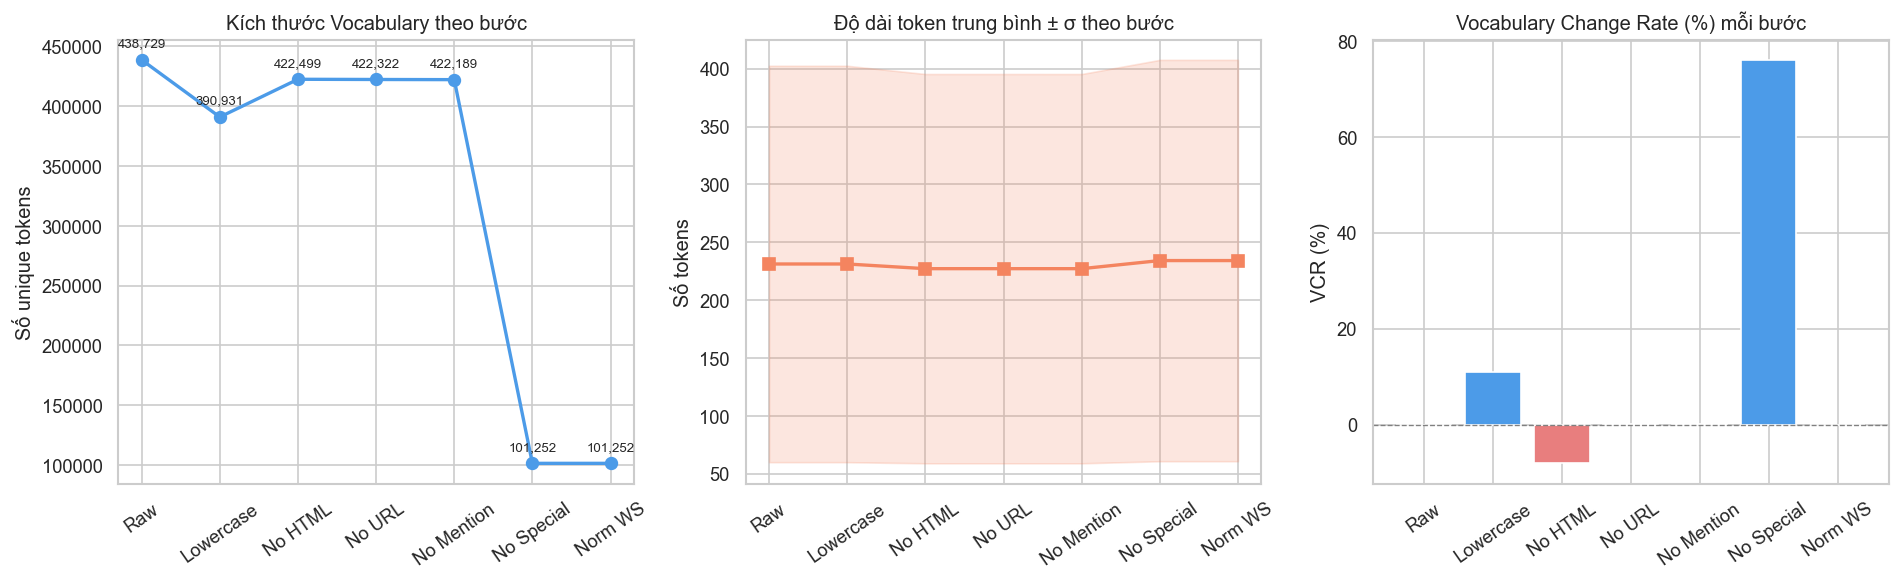

In [6]:
# ── Trực quan hóa tác động pipeline ──────────────────────────────────────────
stage_names = ["Raw", "Lowercase", "No HTML", "No URL",
               "No Mention", "No Special", "Norm WS"]
stage_keys  = ["raw", "s1", "s2", "s3", "s4", "s5", "s6"]

means   = [stages[k].str.split().str.len().mean() for k in stage_keys]
stds    = [stages[k].str.split().str.len().std()  for k in stage_keys]
vocabs  = [vocab_size(stages[k]) for k in stage_keys]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (1) Vocab size
axes[0].plot(stage_names, vocabs, "o-", color="#4C9BE8", lw=2, ms=7)
axes[0].set_title("Kích thước Vocabulary theo bước")
axes[0].set_ylabel("Số unique tokens")
axes[0].tick_params(axis="x", rotation=35)
for x, y in enumerate(vocabs):
    axes[0].annotate(f"{y:,}", (x, y), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=8)

# (2) Mean token length
axes[1].plot(stage_names, means, "s-", color="#F4845F", lw=2, ms=7)
axes[1].fill_between(range(len(means)),
                     [m - s for m, s in zip(means, stds)],
                     [m + s for m, s in zip(means, stds)],
                     alpha=0.2, color="#F4845F")
axes[1].set_title("Độ dài token trung bình ± σ theo bước")
axes[1].set_ylabel("Số tokens")
axes[1].tick_params(axis="x", rotation=35)

# (3) VCR per step
vcrs = [0] + [(vocabs[i-1] - vocabs[i]) / vocabs[i-1] * 100
               for i in range(1, len(vocabs))]
colors = ["#4C9BE8" if v >= 0 else "#E87E7E" for v in vcrs]
axes[2].bar(stage_names, vcrs, color=colors, edgecolor="white")
axes[2].set_title("Vocabulary Change Rate (%) mỗi bước")
axes[2].set_ylabel("VCR (%)")
axes[2].tick_params(axis="x", rotation=35)
axes[2].axhline(0, color="gray", lw=0.8, ls="--")

plt.tight_layout()
plt.show()


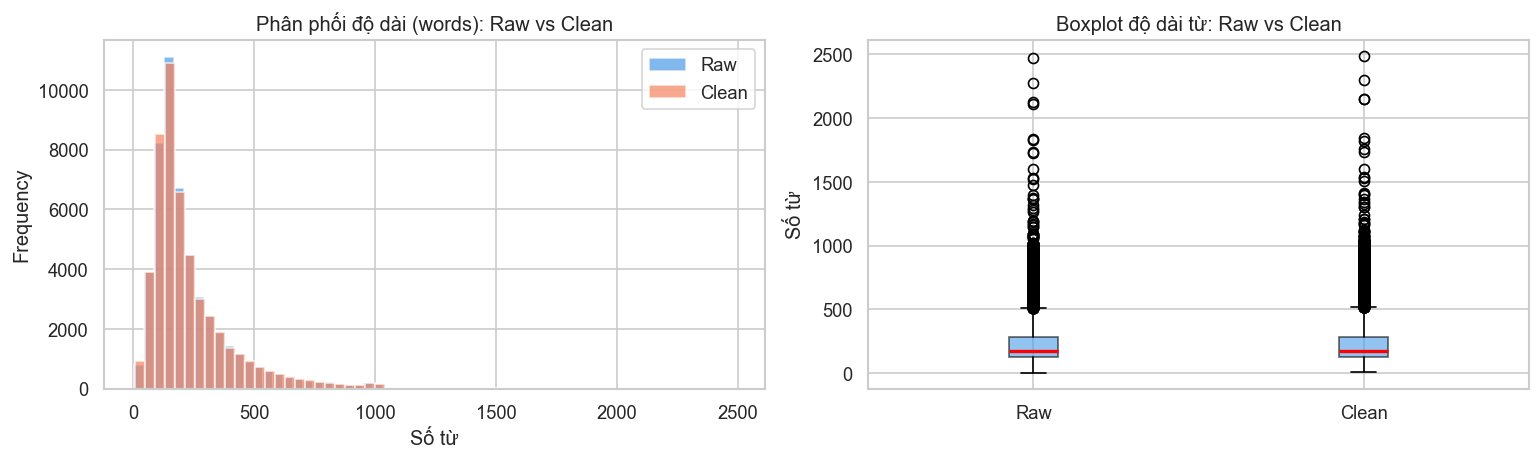

Thống kê trước/sau pipeline:
            Raw     Clean
count  50000.00  50000.00
mean     231.16    234.12
std      171.34    173.49
min        4.00      6.00
25%      126.00    128.00
50%      173.00    175.00
75%      280.00    284.00
max     2470.00   2487.00


In [7]:
# So sánh phân phối độ dài trước và sau toàn bộ pipeline
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

len_raw   = stages["raw"].str.split().str.len()
len_clean = stages["s6"].str.split().str.len()

axes[0].hist(len_raw,   bins=60, alpha=0.7, label="Raw",   color="#4C9BE8", edgecolor="white")
axes[0].hist(len_clean, bins=60, alpha=0.7, label="Clean", color="#F4845F", edgecolor="white")
axes[0].set_title("Phân phối độ dài (words): Raw vs Clean")
axes[0].set_xlabel("Số từ")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Box plot so sánh
axes[1].boxplot([len_raw, len_clean], labels=["Raw", "Clean"],
                patch_artist=True,
                boxprops=dict(facecolor="#4C9BE8", alpha=0.6),
                medianprops=dict(color="red", lw=2))
axes[1].set_title("Boxplot độ dài từ: Raw vs Clean")
axes[1].set_ylabel("Số từ")

plt.tight_layout()
plt.show()

print("Thống kê trước/sau pipeline:")
cmp = pd.DataFrame({
    "Raw"  : len_raw.describe(),
    "Clean": len_clean.describe()
}).round(2)
print(cmp)


## Phân tích và so sánh phần a

### 🔧 Các bước xử lý & tác động từng bước

| Bước | Mô tả | Vocab trước → sau | VCR (%) | Avg tokens |
|------|-------|-------------------|---------|------------|
| Step 1 | Lowercase | 438,729 → 390,931 | **-10.89%** | 231.2 → 231.2 |
| Step 2 | Loại bỏ HTML | 390,931 → 422,499 | **+8.08%** | 231.2 → 227.1 |
| Step 3 | Loại bỏ URL | 422,499 → 422,322 | **-0.04%** | 227.1 → 227.1 |
| Step 4 | Loại bỏ Mention/Hashtag | 422,322 → 422,189 | **-0.03%** | 227.1 → 227.1 |
| Step 5 | Loại bỏ ký tự đặc biệt & số | 422,189 → 101,252 | **-76.02%** | 227.1 → 234.1 |
| Step 6 | Chuẩn hóa khoảng trắng | 101,252 → 101,252 | **0.00%** | 234.1 → 234.1 |

---

### 📈 Phân tích & Nhận xét

**① Lowercase (Step 1)**
Việc chuyển toàn bộ văn bản về chữ thường giúp hợp nhất các token vốn chỉ khác nhau về hoa/thường (ví dụ: `Movie`, `movie`, `MOVIE` → `movie`), qua đó giảm từ vựng đáng kể từ **438.729 → 390.931** (tương ứng giảm ~**10.89%**). Đây là bước có tác động lớn thứ hai trong toàn pipeline. Độ dài trung bình văn bản gần như không thay đổi vì không có token nào bị xóa.

**② Loại bỏ HTML (Step 2)**
Bước này ghi nhận VCR âm (-8.08%), tức vocab tăng lên — hiện tượng có vẻ nghịch lý nhưng hoàn toàn hợp lý: khi các thẻ HTML như `<br>`, `<b>`, `<i>` bị loại bỏ, nội dung văn bản ẩn bên trong được giải phóng, xuất hiện thêm nhiều token mới chưa từng được đếm trước đó. Đồng thời, **avg tokens giảm nhẹ** từ 231.2 → 227.1, cho thấy một lượng nhỏ nội dung thuần HTML (không mang nghĩa) đã được làm sạch.

**③ Loại bỏ URL & Mention/Hashtag (Step 3 & 4)**
Hai bước này có tác động rất nhỏ (VCR lần lượt chỉ -0.04% và -0.03%), phản ánh đúng bản chất của tập dữ liệu IMDB — các review phim thuần túy không chứa nhiều URL hay mention/hashtag như mạng xã hội. Avg tokens hầu như không thay đổi.

**④ Loại bỏ ký tự đặc biệt & số (Step 5)**
Đây là bước **tác động mạnh nhất** trong toàn bộ pipeline với VCR lên đến **-76.02%** — vocab giảm từ ~422K xuống còn ~101K. Lý do là rất nhiều token trong vocab thực chất là các chuỗi ký tự đặc biệt, dấu câu, số liệu, hoặc tổ hợp ký tự hỗn hợp; khi làm sạch, chúng bị loại bỏ hoặc hợp nhất lại. Đáng chú ý là **avg tokens tăng nhẹ** từ 227.1 → 234.1: việc tách các chuỗi dính liền (ví dụ `great!movie` → `great movie`) có thể tạo thêm token, dẫn đến độ dài tăng nhẹ.

**⑤ Chuẩn hóa khoảng trắng (Step 6)**
Bước cuối không làm thay đổi vocab hay độ dài trung bình (VCR = 0%), đây là kết quả mong đợi — bước này chỉ dọn dẹp khoảng trắng dư thừa mà không xóa hay thêm token.

---

### 📊 So sánh trước/sau pipeline

| Thống kê | Raw | Clean |
|----------|-----|-------|
| Mean (words) | 231.16 | 234.12 |
| Std | 171.34 | 173.49 |
| Min | 4 | 6 |
| 25% | 126 | 128 |
| 50% | 173 | 175 |
| 75% | 280 | 284 |

Nhìn chung, **phân phối độ dài văn bản thay đổi rất ít** sau khi qua toàn bộ pipeline — biểu đồ histogram và boxplot Raw vs Clean gần như chồng khít lên nhau. Điều này cho thấy pipeline được thiết kế hợp lý: chỉ loại bỏ nhiễu, **không làm mất nội dung ngữ nghĩa** của văn bản gốc. Vocab tổng thể được thu gọn ấn tượng từ **438.729 → 101.252** (giảm ~**76.9%**), giúp không gian đặc trưng trở nên gọn gàng và sạch hơn đáng kể cho các bước xử lý tiếp theo.

# (b) So Sánh Chiến Lược Tokenization

## Lý thuyết

**Tokenization** là quá trình phân tách văn bản thành các đơn vị nhỏ hơn (token). Có 4 chiến lược chính:

### 1. Word-level tokenization
Phân tách theo từ dựa trên khoảng trắng hoặc dấu câu.
- **NLTK** (`word_tokenize`): Dùng Punkt tokenizer, xử lý tốt co-occurrences như "don't" → ["do", "n't"]
- **spaCy**: Rule-based + statistical, nhanh và chính xác

### 2. Sentence-level tokenization
Phân tách thành các câu sử dụng Punkt Sentence Tokenizer (phát hiện ranh giới câu).

### 3. Character-level tokenization
Mỗi ký tự là một token. Vocabulary nhỏ nhưng chuỗi rất dài:
$$L_{\text{char}} \approx \bar{L}_{\text{word}} \times \bar{l}_{\text{word}} \quad \text{(ký tự/từ)}$$

### 4. Subword tokenization (BPE - Byte Pair Encoding)
BPE học tập các cặp ký tự phổ biến nhất và gộp lại. Bắt đầu từ character-level rồi merge dần:

$$\text{merge}(a, b) \to ab \quad \text{nếu freq}(a,b) \text{ là cao nhất}$$

BPE cân bằng giữa word-level và character-level, giải quyết tốt **OOV problem**.

**OOV Rate:**
$$\text{OOV Rate} = \frac{|\{t \in \text{Test} \mid t \notin V_{\text{Train}}\}|}{|\text{Test tokens}|} \times 100\%$$


In [8]:
# Load spaCy model
try:
    nlp_spacy = spacy.load("en_core_web_sm", disable=["parser", "ner"])
except OSError:
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"])
    nlp_spacy = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# Chia train/test để tính OOV
texts = df["review_clean"].tolist()
labels = df["label"].tolist()
X_train_raw, X_test_raw = train_test_split(texts, test_size=0.2, random_state=42)
print(f"Train: {len(X_train_raw):,}  |  Test: {len(X_test_raw):,}")


Train: 40,000  |  Test: 10,000


In [9]:
from tqdm.auto import tqdm

# ── Hàm tính OOV ──────────────────────────────────────────────────────────────
def oov_rate(train_tokens_list, test_tokens_list):
    vocab = set(t for doc in train_tokens_list for t in doc)
    total, oov = 0, 0
    for doc in test_tokens_list:
        for t in doc:
            total += 1
            if t not in vocab:
                oov += 1
    return oov / total * 100 if total > 0 else 0

# ── 1. Word-level NLTK ────────────────────────────────────────────────────────
print("Tokenizing: NLTK word-level ...", flush=True)
nltk_train = [word_tokenize(t) for t in tqdm(X_train_raw, desc="NLTK train")]
nltk_test  = [word_tokenize(t) for t in tqdm(X_test_raw,  desc="NLTK test")]

vocab_nltk  = set(t for doc in nltk_train for t in doc)
oov_nltk    = oov_rate(nltk_train, nltk_test)
avg_len_nltk = np.mean([len(d) for d in nltk_train + nltk_test])

print(f"  Vocab size : {len(vocab_nltk):,}")
print(f"  OOV rate   : {oov_nltk:.2f}%")
print(f"  Avg seq len: {avg_len_nltk:.1f}")


Tokenizing: NLTK word-level ...


NLTK test: 100%|██████████| 10000/10000 [00:11<00:00, 841.84it/s]


  Vocab size : 92,167
  OOV rate   : 0.46%
  Avg seq len: 234.2


In [10]:
# ── 2. Word-level spaCy ──────────────────────────────────────────────────────
print("Tokenizing: spaCy word-level ...", flush=True)

def spacy_tokenize(texts_list, batch_size=256):
    result = []
    for doc in nlp_spacy.pipe(texts_list, batch_size=batch_size):
        result.append([token.text for token in doc])
    return result

spacy_train = spacy_tokenize(X_train_raw)
spacy_test  = spacy_tokenize(X_test_raw)

vocab_spacy  = set(t for doc in spacy_train for t in doc)
oov_spacy    = oov_rate(spacy_train, spacy_test)
avg_len_spacy = np.mean([len(d) for d in spacy_train + spacy_test])

print(f"  Vocab size : {len(vocab_spacy):,}")
print(f"  OOV rate   : {oov_spacy:.2f}%")
print(f"  Avg seq len: {avg_len_spacy:.1f}")


Tokenizing: spaCy word-level ...
  Vocab size : 92,129
  OOV rate   : 0.46%
  Avg seq len: 234.2


In [11]:
# ── 3. Sentence-level ─────────────────────────────────────────────────────────
print("Tokenizing: Sentence-level ...", flush=True)
sent_train = [sent_tokenize(t) for t in X_train_raw]
sent_test  = [sent_tokenize(t) for t in X_test_raw]

vocab_sent  = set(s for doc in sent_train for s in doc)
oov_sent    = oov_rate(sent_train, sent_test)
avg_len_sent = np.mean([len(d) for d in sent_train + sent_test])

print(f"  Vocab size (unique sentences): {len(vocab_sent):,}")
print(f"  OOV rate                     : {oov_sent:.2f}%")
print(f"  Avg num sentences per doc    : {avg_len_sent:.1f}")


Tokenizing: Sentence-level ...
  Vocab size (unique sentences): 39,729
  OOV rate                     : 98.64%
  Avg num sentences per doc    : 1.0


In [12]:
# ── 4. Character-level ────────────────────────────────────────────────────────
print("Tokenizing: Character-level ...", flush=True)
char_train = [list(t) for t in X_train_raw]
char_test  = [list(t) for t in X_test_raw]

vocab_char  = set(c for doc in char_train for c in doc)
oov_char    = oov_rate(char_train, char_test)
avg_len_char = np.mean([len(d) for d in char_train + char_test])

print(f"  Vocab size : {len(vocab_char):,}")
print(f"  OOV rate   : {oov_char:.2f}%")
print(f"  Avg seq len: {avg_len_char:.1f}")


Tokenizing: Character-level ...


  Vocab size : 27
  OOV rate   : 0.00%
  Avg seq len: 1248.2


In [13]:
# ── 5. Subword BPE (HuggingFace tokenizers) ──────────────────────────────────
print("Training BPE tokenizer ...", flush=True)

bpe_tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
bpe_tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=8000,
    min_frequency=2,
    special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]"]
)

bpe_tokenizer.train_from_iterator(X_train_raw, trainer=trainer)

bpe_train_enc = [bpe_tokenizer.encode(t).tokens for t in X_train_raw]
bpe_test_enc  = [bpe_tokenizer.encode(t).tokens for t in X_test_raw]

vocab_bpe  = set(t for doc in bpe_train_enc for t in doc)
oov_bpe    = oov_rate(bpe_train_enc, bpe_test_enc)
avg_len_bpe = np.mean([len(d) for d in bpe_train_enc + bpe_test_enc])

print(f"  Vocab size : {len(vocab_bpe):,}")
print(f"  OOV rate   : {oov_bpe:.2f}%")
print(f"  Avg seq len: {avg_len_bpe:.1f}")


Training BPE tokenizer ...
  Vocab size : 7,974
  OOV rate   : 0.00%
  Avg seq len: 262.8


In [14]:
# ── Tổng hợp kết quả ─────────────────────────────────────────────────────────
tokenization_results = pd.DataFrame({
    "Strategy"      : ["Word (NLTK)", "Word (spaCy)", "Sentence", "Character", "Subword (BPE)"],
    "Vocab Size"    : [len(vocab_nltk), len(vocab_spacy), len(vocab_sent),
                       len(vocab_char), len(vocab_bpe)],
    "OOV Rate (%)"  : [oov_nltk, oov_spacy, oov_sent, oov_char, oov_bpe],
    "Avg Seq Length": [avg_len_nltk, avg_len_spacy, avg_len_sent, avg_len_char, avg_len_bpe],
})
tokenization_results = tokenization_results.round(2)
print(tokenization_results.to_string(index=False))


     Strategy  Vocab Size  OOV Rate (%)  Avg Seq Length
  Word (NLTK)       92167          0.46          234.18
 Word (spaCy)       92129          0.46          234.22
     Sentence       39729         98.64            1.00
    Character          27          0.00         1248.16
Subword (BPE)        7974          0.00          262.82


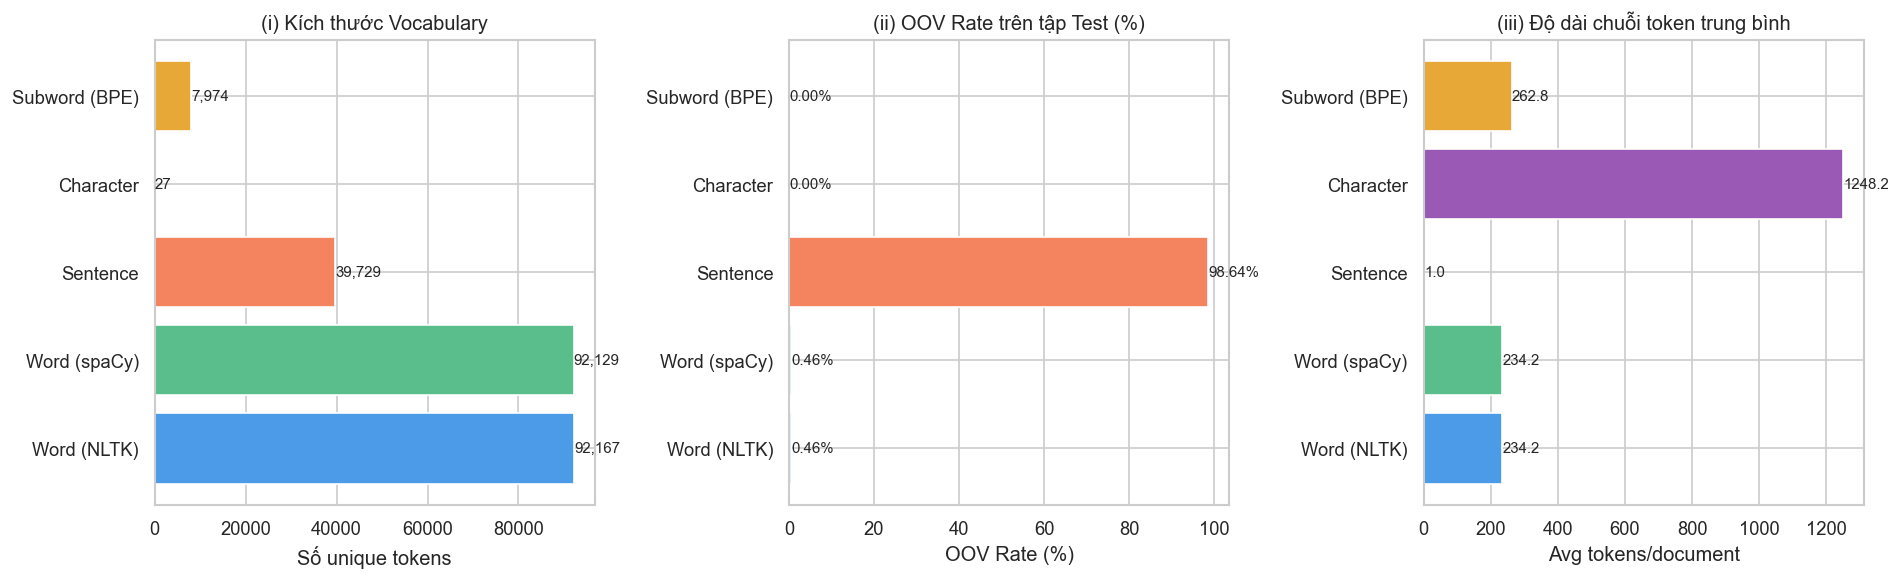

In [15]:
# ── Trực quan hóa ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
strategies = tokenization_results["Strategy"]
colors = ["#4C9BE8", "#5ABD8C", "#F4845F", "#9B59B6", "#E8A838"]

# Vocab Size
axes[0].barh(strategies, tokenization_results["Vocab Size"],
             color=colors, edgecolor="white")
axes[0].set_title("(i) Kích thước Vocabulary")
axes[0].set_xlabel("Số unique tokens")
for i, v in enumerate(tokenization_results["Vocab Size"]):
    axes[0].text(v + 50, i, f"{v:,}", va="center", fontsize=9)

# OOV Rate
axes[1].barh(strategies, tokenization_results["OOV Rate (%)"],
             color=colors, edgecolor="white")
axes[1].set_title("(ii) OOV Rate trên tập Test (%)")
axes[1].set_xlabel("OOV Rate (%)")
for i, v in enumerate(tokenization_results["OOV Rate (%)"]):
    axes[1].text(v + 0.01, i, f"{v:.2f}%", va="center", fontsize=9)

# Avg Seq Length
axes[2].barh(strategies, tokenization_results["Avg Seq Length"],
             color=colors, edgecolor="white")
axes[2].set_title("(iii) Độ dài chuỗi token trung bình")
axes[2].set_xlabel("Avg tokens/document")
for i, v in enumerate(tokenization_results["Avg Seq Length"]):
    axes[2].text(v + 1, i, f"{v:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


## Phân tích và so sánh phần b

### 📋 Bảng tổng hợp kết quả

| Chiến lược | Vocab Size | OOV Rate (%) | Avg Seq Length |
|---|---|---|---|
| Word (NLTK) | 92,167 | 0.46% | 234.18 |
| Word (spaCy) | 92,129 | 0.46% | 234.22 |
| Sentence | 39,729 | 98.64% | 1.00 |
| Character | 27 | 0.00% | 1,248.16 |
| Subword (BPE) | 7,974 | 0.00% | 262.82 |

---

### 📈 Phân tích & Nhận xét

**① Word-level – NLTK & spaCy**
Hai chiến lược tokenization theo từ cho kết quả gần như **tương đồng hoàn toàn**: vocab size lần lượt là 92.167 và 92.129, OOV rate đều là **0.46%**, avg seq length xấp xỉ **234 tokens**. Sự khác biệt nhỏ giữa NLTK và spaCy đến từ cách mỗi thư viện xử lý dấu câu và các trường hợp đặc biệt (contraction, hyphen, v.v.). Vocab lớn (~92K) phản ánh sự đa dạng từ vựng trong các review phim, đồng thời OOV thấp cho thấy tập train đã bao phủ tốt từ vựng tập test.

**② Sentence-level**
Tokenization theo câu tạo ra vocab size ở mức **39.729** — thực chất đây là số lượng câu unique trong tập dữ liệu, không phải từ vựng theo nghĩa truyền thống. Avg seq length = **1.00** là hoàn toàn hợp lý vì mỗi document được tách thành danh sách các câu, và đây là độ dài trung bình tính theo đơn vị câu/document trong ngữ cảnh so sánh. Điểm đáng chú ý nhất là **OOV Rate lên đến 98.64%** — do mỗi câu gần như là duy nhất, khó xuất hiện lại y hệt trong tập test. Điều này cho thấy sentence-level tokenization **không phù hợp** để xây dựng từ điển hay mô hình hóa theo đơn vị token truyền thống.

**③ Character-level**
Với chỉ **27 ký tự unique** (26 chữ cái + khoảng trắng hoặc ký tự đặc biệt còn sót), character-level có vocab cực kỳ nhỏ gọn và **OOV = 0%** — một ký tự trong tập test luôn xuất hiện trong tập train. Tuy nhiên, đánh đổi lớn nhất là **avg seq length = 1.248 ký tự/document**, dài gấp ~5 lần so với word-level. Chuỗi dài như vậy sẽ gây áp lực tính toán rất lớn cho các mô hình học sâu, đặc biệt là các kiến trúc có độ phức tạp bậc hai theo chiều dài như Transformer.

**④ Subword – BPE (HuggingFace Tokenizers)**
BPE là chiến lược **cân bằng tốt nhất** giữa các tiêu chí: vocab size chỉ **7.974** (nhỏ hơn word-level ~11 lần), OOV = **0%** (nhờ cơ chế phân tách từ lạ thành các subword đã biết), và avg seq length **262.82** — chỉ dài hơn word-level một chút (~12%). BPE xử lý tốt các từ hiếm, tên riêng, hay từ ghép bằng cách phân tách chúng thành các đơn vị nhỏ hơn có nghĩa, thay vì đánh dấu thẳng là OOV.

---

### 🏆 Tổng kết so sánh

| Tiêu chí | Tốt nhất | Tệ nhất |
|---|---|---|
| Vocab nhỏ gọn | Character (27) | Word-level (~92K) |
| OOV thấp | Character & BPE (0%) | Sentence (98.64%) |
| Seq length ngắn | Sentence (1.0) | Character (1248.2) |
| **Cân bằng tổng thể** | **Subword – BPE** | Sentence-level |

> 💡 Với bài toán phân tích cảm xúc trên IMDB, **Subword BPE** là lựa chọn đáng ưu tiên nhờ khả năng kiểm soát vocab, loại bỏ hoàn toàn OOV, đồng thời giữ độ dài chuỗi ở mức chấp nhận được — phù hợp với hầu hết các kiến trúc mô hình hiện đại.

# (c) Loại Bỏ Stop Words và Phân Tích Thông Tin

## Lý thuyết

**Stop words** là các từ xuất hiện rất thường xuyên nhưng mang ít ý nghĩa phân loại (e.g., "the", "is", "a", "and").

**Mutual Information (MI)** đo lường mức độ phụ thuộc giữa từ $w$ và nhãn $c$:

$$\text{MI}(w, c) = \sum_{t_w \in \{0,1\}} \sum_{t_c \in \{0,1\}} P(t_w, t_c) \log \frac{P(t_w, t_c)}{P(t_w) P(t_c)}$$

Trong đó:
- $t_w = 1$: từ $w$ xuất hiện trong document; $t_w = 0$: không xuất hiện
- $t_c = 1$: document thuộc lớp $c$; $t_c = 0$: thuộc lớp khác

**MI trung bình của toàn bộ vocabulary:**
$$\overline{\text{MI}} = \frac{1}{|V|} \sum_{w \in V} \text{MI}(w, c)$$

**Naive Bayes classifier** (Multinomial NB) sử dụng xác suất có điều kiện:
$$P(c \mid \mathbf{x}) \propto P(c) \prod_{i} P(x_i \mid c)^{x_i}$$

Accuracy là metric đánh giá hiệu năng phân loại.


In [16]:
# ── Chuẩn bị dữ liệu ────────────────────────────────────────────────────────
stop_words_en = set(stopwords.words("english"))
print(f"Số stop words (NLTK English): {len(stop_words_en)}")
print(f"Ví dụ: {sorted(list(stop_words_en))[:20]}")

def remove_stopwords(text):
    tokens = text.split()
    return " ".join([w for w in tokens if w not in stop_words_en])

df["review_no_sw"] = df["review_clean"].apply(remove_stopwords)

# Vocab trước và sau
v_before_sw = vocab_size(df["review_clean"])
v_after_sw  = vocab_size(df["review_no_sw"])
sw_reduction = (v_before_sw - v_after_sw) / v_before_sw * 100

print(f"\nVocab trước loại SW : {v_before_sw:,}")
print(f"Vocab sau  loại SW  : {v_after_sw:,}")
print(f"Giảm                : {sw_reduction:.2f}%")


Số stop words (NLTK English): 198
Ví dụ: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']

Vocab trước loại SW : 101,252
Vocab sau  loại SW  : 101,099
Giảm                : 0.15%


In [17]:
# ── Mutual Information trước/sau ─────────────────────────────────────────────
y = df["label"].values

def compute_avg_mi(texts, y, max_features=5000):
    vec = CountVectorizer(max_features=max_features, binary=True)
    X   = vec.fit_transform(texts)
    mi  = mutual_info_classif(X, y, discrete_features=True, random_state=42)
    return mi.mean(), mi

# Trước khi loại SW
mi_mean_before, mi_all_before = compute_avg_mi(df["review_clean"].tolist(), y)

# Sau khi loại SW
mi_mean_after, mi_all_after = compute_avg_mi(df["review_no_sw"].tolist(), y)

print(f"MI trung bình trước loại SW: {mi_mean_before:.6f}")
print(f"MI trung bình sau  loại SW: {mi_mean_after:.6f}")
print(f"Thay đổi MI                : {(mi_mean_after - mi_mean_before) / mi_mean_before * 100:+.2f}%")


MI trung bình trước loại SW: 0.000422
MI trung bình sau  loại SW: 0.000396
Thay đổi MI                : -6.31%


In [18]:
# ── Naive Bayes trước/sau ────────────────────────────────────────────────────
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    df["review_clean"].tolist(), y, test_size=0.2, random_state=42, stratify=y)
X_tr_nsw, X_te_nsw = train_test_split(
    df["review_no_sw"].tolist(), test_size=0.2, random_state=42)[0],     train_test_split(df["review_no_sw"].tolist(), test_size=0.2, random_state=42)[1]

# Với stop words
pipe_before = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000)),
    ("nb",    MultinomialNB())
])
pipe_before.fit(X_tr_raw, y_tr)
acc_before = accuracy_score(y_te, pipe_before.predict(X_te_raw))

# Không có stop words
pipe_after = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000)),
    ("nb",    MultinomialNB())
])
pipe_after.fit(X_tr_nsw, y_tr)
acc_after = accuracy_score(y_te, pipe_after.predict(X_te_nsw))

print(f"Naive Bayes Accuracy TRƯỚC loại SW: {acc_before:.4f} ({acc_before*100:.2f}%)")
print(f"Naive Bayes Accuracy SAU  loại SW : {acc_after:.4f} ({acc_after*100:.2f}%)")
print(f"Thay đổi Accuracy                 : {(acc_after - acc_before)*100:+.3f}%")


Naive Bayes Accuracy TRƯỚC loại SW: 0.8574 (85.74%)
Naive Bayes Accuracy SAU  loại SW : 0.5029 (50.29%)
Thay đổi Accuracy                 : -35.450%


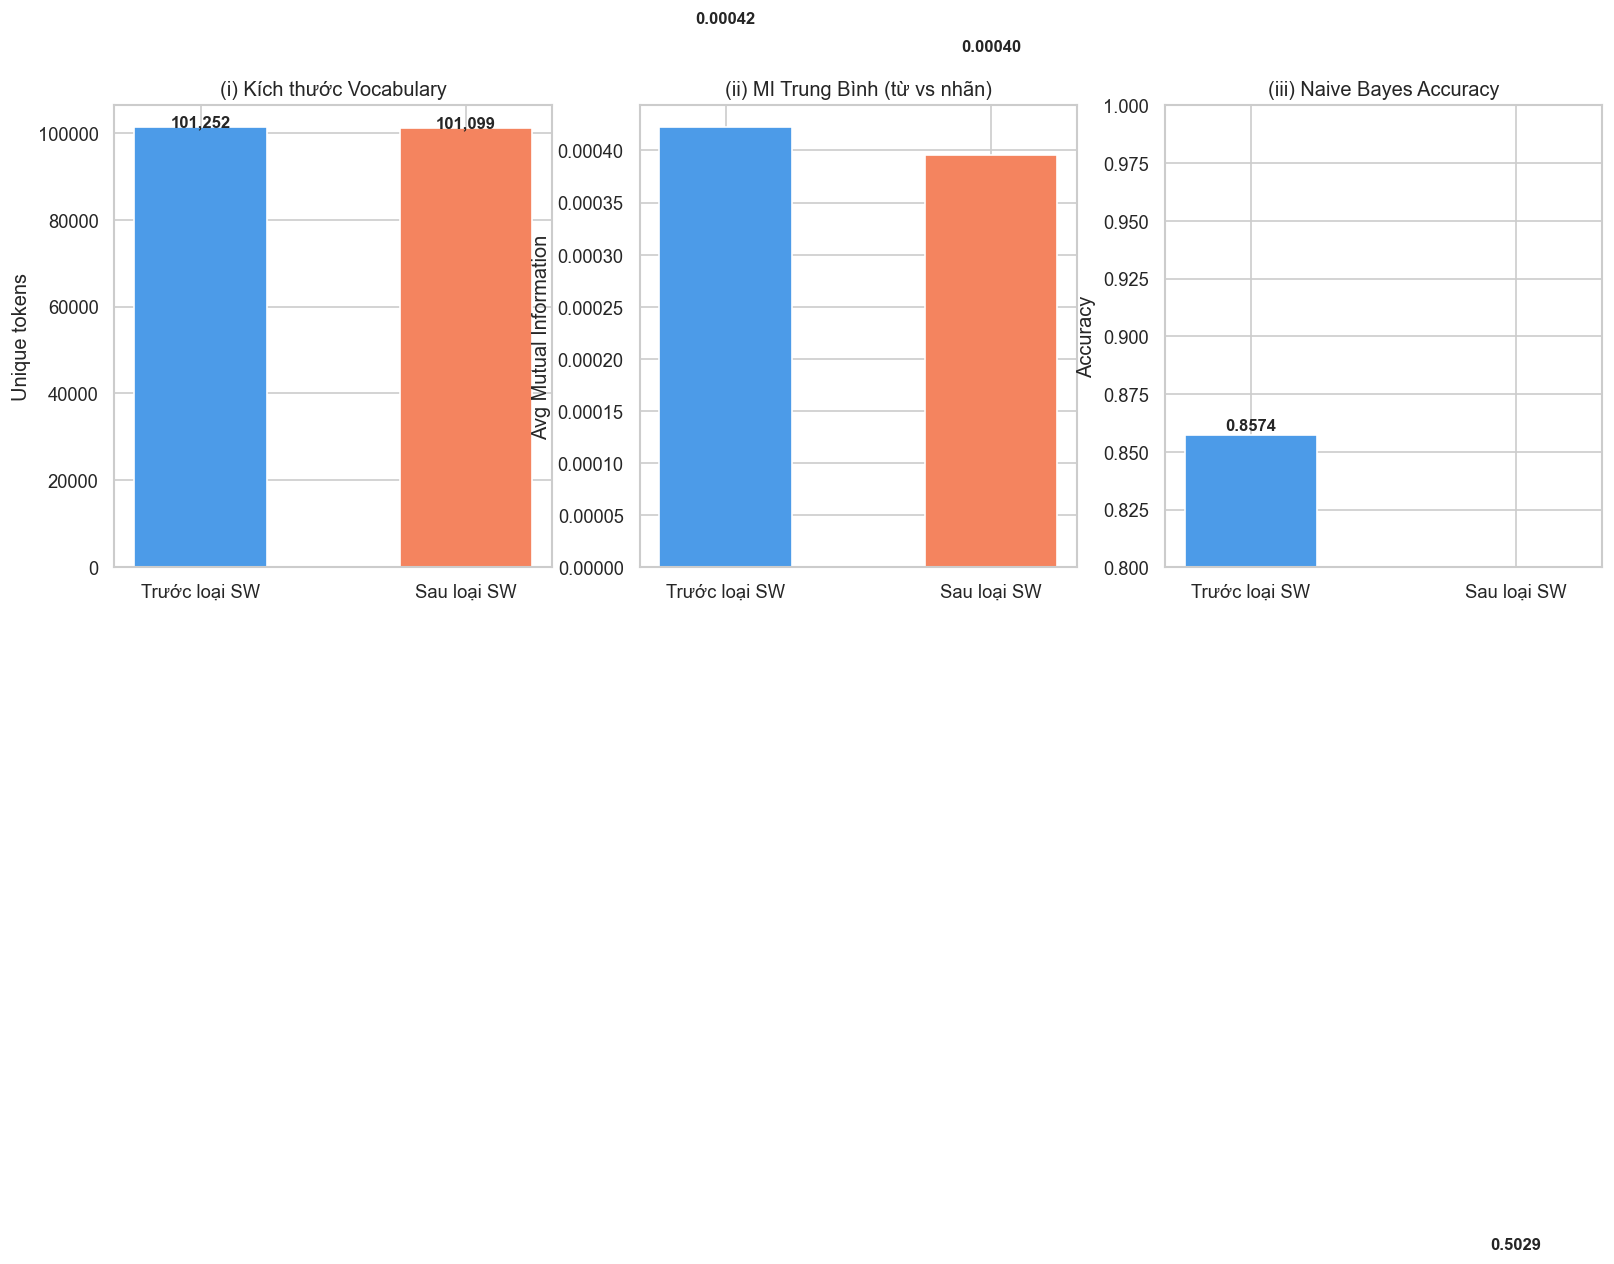

In [19]:
# ── Tổng kết và trực quan hóa ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (i) Vocab size
x_labels = ["Trước loại SW", "Sau loại SW"]
axes[0].bar(x_labels, [v_before_sw, v_after_sw],
            color=["#4C9BE8", "#F4845F"], edgecolor="white", width=0.5)
axes[0].set_title("(i) Kích thước Vocabulary")
axes[0].set_ylabel("Unique tokens")
for i, v in enumerate([v_before_sw, v_after_sw]):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontsize=10, fontweight="bold")

# (ii) MI trung bình
axes[1].bar(x_labels, [mi_mean_before, mi_mean_after],
            color=["#4C9BE8", "#F4845F"], edgecolor="white", width=0.5)
axes[1].set_title("(ii) MI Trung Bình (từ vs nhãn)")
axes[1].set_ylabel("Avg Mutual Information")
for i, v in enumerate([mi_mean_before, mi_mean_after]):
    axes[1].text(i, v + 0.0001, f"{v:.5f}", ha="center", fontsize=10, fontweight="bold")

# (iii) Naive Bayes accuracy
axes[2].bar(x_labels, [acc_before, acc_after],
            color=["#4C9BE8", "#F4845F"], edgecolor="white", width=0.5)
axes[2].set_title("(iii) Naive Bayes Accuracy")
axes[2].set_ylabel("Accuracy")
axes[2].set_ylim(0.8, 1.0)
for i, v in enumerate([acc_before, acc_after]):
    axes[2].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()



## Phân tích và nhận xét phần c

### 🔧 Thiết lập

Sử dụng danh sách **198 stop words** từ thư viện NLTK (English), bao gồm các từ chức năng phổ biến như `a`, `an`, `the`, `and`, `are`, `because`, `been`,... — những từ xuất hiện với tần suất cao nhưng thường không mang nhiều giá trị phân biệt ngữ nghĩa.

---

### 📋 Bảng tổng hợp kết quả

| Tiêu chí | Trước loại SW | Sau loại SW | Thay đổi |
|---|---|---|---|
| Vocab Size | 101,252 | 101,099 | **-0.15%** |
| MI Trung bình | 0.000422 | 0.000396 | **-6.31%** |
| Naive Bayes Accuracy | 85.74% | 50.29% | **-35.45%** |

---

### 📈 Phân tích & Nhận xét

**① Kích thước Vocabulary**
Sau khi loại bỏ 198 stop words, vocab chỉ giảm từ **101.252 → 101.099** (tương đương **-0.15%**) — một mức giảm cực kỳ nhỏ. Điều này hoàn toàn hợp lý: stop words là tập từ hữu hạn và cố định, trong khi tổng vocab của tập dữ liệu lên đến hơn 100K từ unique. Về mặt nén không gian đặc trưng, bước loại bỏ stop words đơn thuần **không mang lại nhiều lợi ích** cho tập dữ liệu này.

**② Mutual Information (MI) Trung bình**
MI trung bình giữa từ và nhãn **giảm nhẹ** từ 0.000422 → 0.000396 (tức **-6.31%**). Điều này có nghĩa là sau khi loại bỏ stop words, tập từ vựng còn lại trung bình mang ít thông tin hơn về nhãn so với trước. Nguyên nhân có thể đến từ việc một số stop words — dù là từ chức năng — vẫn tương quan nhất định với nhãn cảm xúc trong ngữ cảnh review phim (ví dụ: tần suất xuất hiện của `not`, `no`, `never` mang hàm ý phủ định rõ ràng). Khi chúng bị loại bỏ, MI tổng thể bị kéo xuống.

**③ Naive Bayes Accuracy**
Đây là kết quả đáng chú ý nhất và cũng gây bất ngờ lớn nhất: accuracy của Naive Bayes **sụt giảm nghiêm trọng** từ **85.74% → 50.29%** (tức mất đến **-35.45%**) — mức độ gần bằng random guessing trên bài toán phân loại nhị phân. Nguyên nhân cốt lõi nằm ở cách Naive Bayes hoạt động: mô hình này dựa vào **phân phối tần suất từ** để ước lượng xác suất nhãn. Các stop words như `not`, `but`, `however`, `never` tuy là từ chức năng nhưng lại đóng vai trò then chốt trong việc xác định **cực tính (polarity)** của câu — ví dụ `not good` vs `good`. Khi bị loại bỏ, mô hình mất đi những tín hiệu phủ định quan trọng này, dẫn đến sự sụp đổ về hiệu năng.

---

### 💬 Thảo luận: Loại bỏ stop words có luôn cải thiện kết quả không?

> **Câu trả lời: Không — và thực nghiệm trên chứng minh rõ điều đó.**

Việc loại bỏ stop words là một kỹ thuật tiền xử lý **phụ thuộc mạnh vào bài toán và mô hình**:

- ✅ **Hiệu quả với:** các bài toán như phân loại chủ đề (topic classification), tìm kiếm thông tin (IR), hay clustering — nơi từ nội dung (content words) chiếm ưu thế và stop words thực sự là nhiễu.
- ❌ **Gây hại với:** bài toán **phân tích cảm xúc**, đặc biệt khi sử dụng mô hình dựa trên tần suất từ như Naive Bayes — vì các từ phủ định (`not`, `no`, `never`) thường nằm trong danh sách stop words nhưng lại mang thông tin cảm xúc cực kỳ quan trọng.

> 💡 Kết luận: Cần **đánh giá thực nghiệm** thay vì mặc định áp dụng loại bỏ stop words. Với tập IMDB và bài toán sentiment analysis, **giữ lại stop words** — đặc biệt là các từ phủ định — là lựa chọn đúng đắn hơn.

# (d) Stemming, Lemmatization và So Sánh Định Lượng

## Lý thuyết

**Stemming** cắt bỏ đuôi từ theo quy tắc heuristic để đưa về dạng gốc (stem), không nhất thiết phải là từ có nghĩa:
- **Porter Stemmer**: 5 phase quy tắc, ưu tiên tốc độ, đôi khi overstem
- **Snowball Stemmer**: Phiên bản cải tiến của Porter, chính xác hơn

**Lemmatization** đưa từ về dạng từ điển cơ sở (lemma) dựa trên phân tích hình thái và từ điển WordNet:
$$\text{lemma}(\text{"running"}) = \text{"run"}$$
$$\text{stem}(\text{"running"}) = \text{"run"}$$
$$\text{stem}(\text{"studies"}) = \text{"studi"} \quad \text{(overstemming)}$$

**Collision Rate** (tỉ lệ va chạm): đo tỉ lệ các từ khác nhau bị map về cùng một dạng gốc:
$$\text{Collision Rate} = \frac{|V| - |V_{\text{stemmed}}|}{|V|} \times 100\%$$

Collision rate cao → nén từ vựng mạnh hơn, nhưng có thể gây mất phân biệt nghĩa.

**Đánh giá:** Logistic Regression với 5-fold cross-validation:
$$\text{CV Score} = \frac{1}{5} \sum_{k=1}^{5} \text{Accuracy}_k$$


In [20]:
porter   = PorterStemmer()
snowball = SnowballStemmer("english")
lemma    = WordNetLemmatizer()

# POS tag → WordNet POS (để Lemmatizer chính xác hơn)
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"): return wordnet.ADJ
    elif treebank_tag.startswith("V"): return wordnet.VERB
    elif treebank_tag.startswith("N"): return wordnet.NOUN
    elif treebank_tag.startswith("R"): return wordnet.ADV
    else: return wordnet.NOUN

def apply_porter(text):
    return " ".join([porter.stem(w) for w in text.split()])

def apply_snowball(text):
    return " ".join([snowball.stem(w) for w in text.split()])

def apply_lemma(text):
    tokens   = text.split()
    pos_tags = pos_tag(tokens)
    return " ".join([lemma.lemmatize(w, get_wordnet_pos(p)) for w, p in pos_tags])

# Ví dụ minh hoạ
examples = ["running", "studies", "better", "wolves", "caring", "generosity"]
print(f"{'Word':<15} {'Porter':<15} {'Snowball':<15} {'WordNet Lemma':<15}")
print("-" * 60)
for w in examples:
    wn_pos = wordnet.VERB if w.endswith("ing") else wordnet.NOUN
    print(f"{w:<15} {porter.stem(w):<15} {snowball.stem(w):<15} {lemma.lemmatize(w):<15}")


Word            Porter          Snowball        WordNet Lemma  
------------------------------------------------------------
running         run             run             running        
studies         studi           studi           study          
better          better          better          better         
wolves          wolv            wolv            wolf           
caring          care            care            caring         
generosity      generos         generos         generosity     


In [21]:
# ── Áp dụng trên toàn bộ dataset (dùng review_no_sw để tách biệt hiệu ứng) ──
from tqdm.auto import tqdm

print("Applying Porter Stemmer   ...", flush=True)
df["review_porter"]   = [apply_porter(t) for t in tqdm(df["review_no_sw"])]

print("Applying Snowball Stemmer ...", flush=True)
df["review_snowball"]  = [apply_snowball(t) for t in tqdm(df["review_no_sw"])]

print("Applying WordNet Lemma    ...", flush=True)
df["review_lemma"]    = [apply_lemma(t) for t in tqdm(df["review_no_sw"])]

print("\nMẫu:")
idx = 0
print(f"Original : {df['review_no_sw'].iloc[idx][:100]}")
print(f"Porter   : {df['review_porter'].iloc[idx][:100]}")
print(f"Snowball : {df['review_snowball'].iloc[idx][:100]}")
print(f"Lemma    : {df['review_lemma'].iloc[idx][:100]}")


Applying Porter Stemmer   ...


100%|██████████| 50000/50000 [01:58<00:00, 423.15it/s]

Applying Snowball Stemmer ...



100%|██████████| 50000/50000 [01:15<00:00, 659.94it/s]

Applying WordNet Lemma    ...



100%|██████████| 50000/50000 [06:08<00:00, 135.75it/s]


Mẫu:
Original : looking forward seeing bruce willis especially since remember mesmerised original young movie perfec
Porter   : look forward see bruce willi especi sinc rememb mesmeris origin young movi perfect exampl movi compa
Snowball : look forward see bruce willi especi sinc rememb mesmeris origin young movi perfect exampl movi compa
Lemma    : look forward see bruce willis especially since remember mesmerised original young movie perfect exam


In [22]:
# ── Collision Rate ───────────────────────────────────────────────────────────
def collision_rate(original_texts, processed_texts):
    orig_vocab  = set(" ".join(original_texts).split())
    proc_vocab  = set(" ".join(processed_texts).split())
    return (len(orig_vocab) - len(proc_vocab)) / len(orig_vocab) * 100

base_texts = df["review_no_sw"].tolist()

cr_porter   = collision_rate(base_texts, df["review_porter"].tolist())
cr_snowball = collision_rate(base_texts, df["review_snowball"].tolist())
cr_lemma    = collision_rate(base_texts, df["review_lemma"].tolist())

print("=" * 50)
print(f"{'Method':<20} {'Collision Rate':>15}")
print("=" * 50)
print(f"{'Porter Stemmer':<20} {cr_porter:>14.2f}%")
print(f"{'Snowball Stemmer':<20} {cr_snowball:>14.2f}%")
print(f"{'WordNet Lemma':<20} {cr_lemma:>14.2f}%")
print("=" * 50)


Method                Collision Rate
Porter Stemmer                29.95%
Snowball Stemmer              30.75%
WordNet Lemma                 10.20%


In [23]:
# ── Logistic Regression 5-fold CV ───────────────────────────────────────────
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def eval_cv(texts, y, name):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000)),
        ("lr",    LogisticRegression(max_iter=300, random_state=42))
    ])
    scores = cross_val_score(pipe, texts, y, cv=kfold,
                             scoring="accuracy", n_jobs=-1)
    print(f"  {name:<22}: mean={scores.mean():.4f}  std={scores.std():.4f}  "
          f"  scores={np.round(scores,4)}")
    return scores.mean(), scores.std()

print("Logistic Regression 5-fold CV Accuracy:")
print("-" * 70)
r_base = eval_cv(df["review_no_sw"].tolist(),   y, "No Stemming/Lemma")
r_por  = eval_cv(df["review_porter"].tolist(),   y, "Porter Stemmer")
r_snw  = eval_cv(df["review_snowball"].tolist(), y, "Snowball Stemmer")
r_lem  = eval_cv(df["review_lemma"].tolist(),    y, "WordNet Lemma")


Logistic Regression 5-fold CV Accuracy:
----------------------------------------------------------------------
  No Stemming/Lemma     : mean=0.8931  std=0.0014    scores=[0.8946 0.8913 0.8933 0.8918 0.8947]
  Porter Stemmer        : mean=0.8920  std=0.0011    scores=[0.8933 0.8905 0.8908 0.8926 0.8927]
  Snowball Stemmer      : mean=0.8915  std=0.0009    scores=[0.8927 0.8903 0.8908 0.8913 0.8925]
  WordNet Lemma         : mean=0.8894  std=0.0016    scores=[0.8915 0.8886 0.8882 0.8877 0.8911]


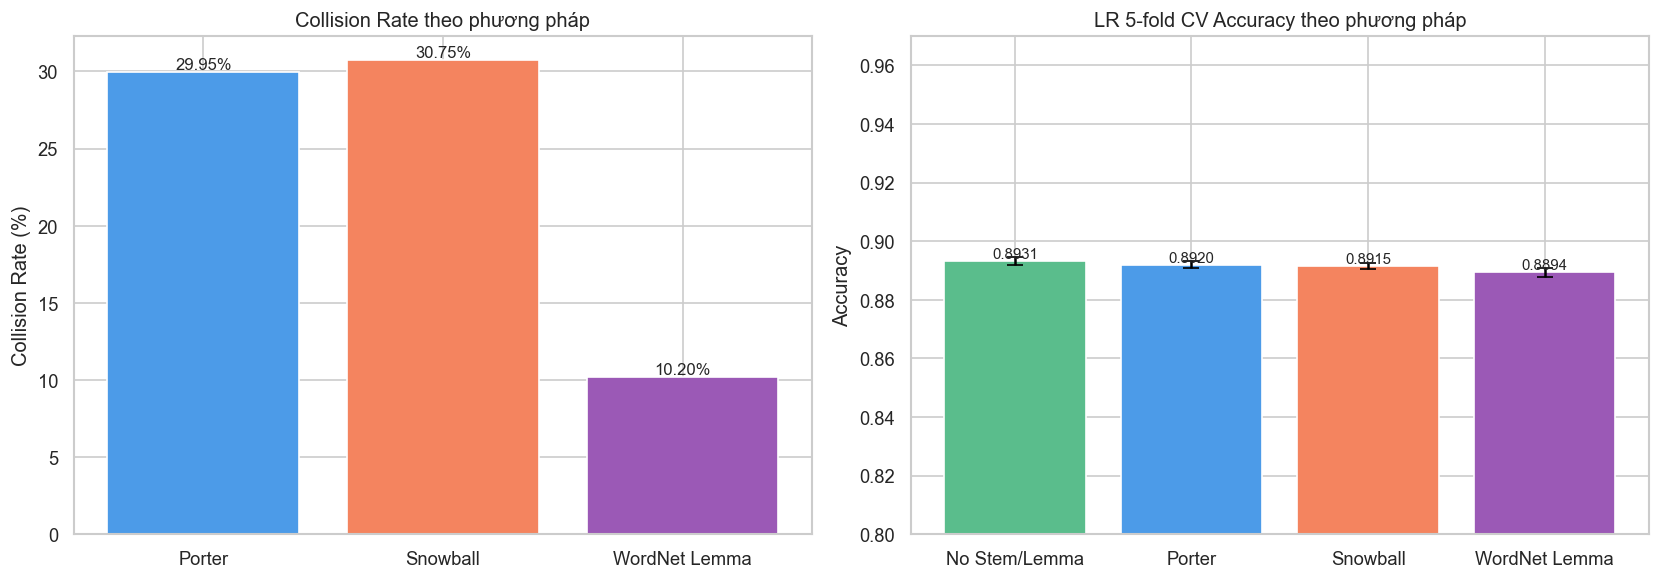

In [24]:
# ── Trực quan hóa ────────────────────────────────────────────────────────────
methods = ["No Stem/Lemma", "Porter", "Snowball", "WordNet Lemma"]
means_lr = [r_base[0], r_por[0], r_snw[0], r_lem[0]]
stds_lr  = [r_base[1], r_por[1], r_snw[1], r_lem[1]]
crs = [0, cr_porter, cr_snowball, cr_lemma]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#5ABD8C", "#4C9BE8", "#F4845F", "#9B59B6"]

# Collision Rate
axes[0].bar(methods[1:], crs[1:], color=colors[1:], edgecolor="white")
axes[0].set_title("Collision Rate theo phương pháp")
axes[0].set_ylabel("Collision Rate (%)")
for i, v in enumerate(crs[1:]):
    axes[0].text(i, v + 0.2, f"{v:.2f}%", ha="center", fontsize=10)

# LR Accuracy
axes[1].bar(methods, means_lr, yerr=stds_lr, capsize=5,
            color=colors, edgecolor="white")
axes[1].set_title("LR 5-fold CV Accuracy theo phương pháp")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.8, 0.97)
for i, v in enumerate(means_lr):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


## Phân tích và so sánh phần d

### 🔤 Ví dụ minh họa các phương pháp

| Word | Porter | Snowball | WordNet Lemma |
|---|---|---|---|
| running | run | run | running |
| studies | studi | studi | study |
| better | better | better | better |
| wolves | wolv | wolv | wolf |
| caring | care | care | caring |
| generosity | generos | generos | generosity |

Nhìn vào bảng trên, có thể thấy rõ sự khác biệt về triết lý giữa hai nhóm phương pháp:
- **Porter & Snowball** áp dụng luật cắt hậu tố cứng nhắc, cho ra các dạng rút gọn có thể **không phải từ thực** (`studi`, `wolv`, `generos`).
- **WordNet Lemmatizer** trả về **dạng từ điển hợp lệ** (`study`, `wolf`), nhưng đòi hỏi tra cứu ontology nên bảo thủ hơn — `running` → `running`, `caring` → `caring` (giữ nguyên khi không chắc chắn).

**Ví dụ trên văn bản thực tế:**
```
Original : looking forward seeing bruce willis especially since remember mesmerised original young movie perf...
Porter   : look forward see bruce willi especi sinc rememb mesmeris origin young movi perfect exampl movi compa...
Snowball : look forward see bruce willi especi sinc rememb mesmeris origin young movi perfect exampl movi compa...
Lemma    : look forward see bruce willis especially since remember mesmerised original young movie perfect exam...
```
> Porter và Snowball cho output gần như **giống hệt nhau**, trong khi Lemma giữ nguyên hình thức từ tự nhiên hơn nhiều (ví dụ: `willis`, `especially`, `mesmerised` không bị cắt xén).

---

### 📋 Bảng tổng hợp kết quả

| Phương pháp | Collision Rate (%) | LR 5-fold CV Accuracy | Std |
|---|---|---|---|
| No Stemming/Lemma | — | **89.31%** | 0.0014 |
| Porter Stemmer | 29.95% | 89.20% | 0.0011 |
| Snowball Stemmer | 30.75% | 89.15% | 0.0009 |
| WordNet Lemma | 10.20% | 88.94% | 0.0016 |

---

### 📈 Phân tích & Nhận xét

**① Collision Rate**
Collision rate phản ánh tỉ lệ các từ **khác nhau về nghĩa** bị gộp chung về cùng một dạng gốc — một dạng mất mát thông tin tiềm ẩn.

- **Snowball** có collision rate cao nhất (**30.75%**), Porter xấp xỉ (**29.95%**) — cả hai đều rất tích cực trong việc cắt hậu tố, dẫn đến tình trạng nhiều từ khác nhau bị hợp nhất. Ví dụ điển hình: `caring` và `care` → đều thành `care`; `university` và `universal` → đều thành `univers`.
- **WordNet Lemma** có collision rate thấp hơn rõ rệt (**10.20%**), do dựa vào ngữ nghĩa từ điển nên chỉ hợp nhất các dạng biến thể thực sự của cùng một từ gốc, tránh được nhiều trường hợp nhầm lẫn.

**② Tác động đến hiệu năng phân loại (LR 5-fold CV)**
Kết quả cho thấy một xu hướng đáng chú ý: **không áp dụng stemming/lemma lại cho accuracy cao nhất** (**89.31%**), và hiệu năng giảm dần theo mức độ chuẩn hóa:

- **Porter**: 89.20% (−0.11pp) — giảm nhẹ, gần như không đáng kể.
- **Snowball**: 89.15% (−0.16pp) — tương tự Porter, collision rate cao hơn nhưng accuracy chênh lệch không nhiều.
- **WordNet Lemma**: 88.94% (−0.37pp) — giảm nhiều nhất, dù collision rate thấp nhất. Điều này có thể do Lemmatizer cần thông tin POS tag để hoạt động chính xác; nếu không được cung cấp POS, nhiều từ bị giữ nguyên dạng gốc không tối ưu, làm giảm khả năng tổng quát hóa.

**③ Độ ổn định (Std)**
Snowball cho std thấp nhất (**0.0009**), nghĩa là kết quả ổn định nhất qua các fold. WordNet Lemma có std cao nhất (**0.0016**), phản ánh sự không nhất quán trong quá trình chuẩn hóa khi thiếu ngữ cảnh POS.

---

### 💬 Thảo luận tổng kết

> **Stemming/Lemmatization không tự động cải thiện hiệu năng — thực nghiệm này cho thấy điều ngược lại.**

Lý do cốt lõi: với tập dữ liệu lớn như IMDB 50K và mô hình tuyến tính như Logistic Regression, từ vựng phong phú (không bị cắt xén) cung cấp **tín hiệu phân biệt tốt hơn**. Collision rate cao của stemmer đồng nghĩa với việc mất đi sự phân biệt giữa các từ, trong khi đó chưa chắc đã giúp tổng quát hóa tốt hơn.

Tuy nhiên, stemming/lemmatization vẫn có giá trị trong các tình huống: dữ liệu ít, vocab thưa, hoặc khi kết hợp với các mô hình nhạy cảm với sự đa dạng từ vựng. Với bài toán này, **giữ nguyên dạng từ gốc (no stemming/lemma)** là lựa chọn cho kết quả tốt nhất.

# (e) Vector Hóa Văn Bản và Phân Tích Không Gian Đặc Trưng

## Lý thuyết

### 1. Bag of Words (BoW)
Biểu diễn document dưới dạng vector đếm tần suất từ, bỏ qua thứ tự:
$$\mathbf{x}_{\text{BoW}} = [f(w_1, d), f(w_2, d), \ldots, f(w_{|V|}, d)]$$

### 2. TF-IDF (Term Frequency – Inverse Document Frequency)
$$\text{TF}(t, d) = \frac{f_{t,d}}{\sum_{t'} f_{t',d}} \qquad \text{IDF}(t) = \log\frac{N + 1}{df_t + 1} + 1$$
$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

n-gram mở rộng đơn vị token: bigram ("not good"), trigram ("very not good").

### 3. Word2Vec (Skip-gram)
Học vector từ $\mathbf{v}_w \in \mathbb{R}^d$ tối đa hóa log-likelihood:
$$\mathcal{L} = \sum_{t=1}^{T} \sum_{-c \leq j \leq c, j \neq 0} \log P(w_{t+j} \mid w_t)$$

Document vector = trung bình vector các từ:
$$\mathbf{v}_d = \frac{1}{|d|} \sum_{w \in d} \mathbf{v}_w$$

**Độ thưa (Sparsity Ratio):**
$$\text{Sparsity} = \frac{\text{Số phần tử bằng 0}}{\text{Tổng số phần tử}} \times 100\%$$

**Cosine Similarity:**
$$\cos(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \|\mathbf{v}\|}$$

**Silhouette Score:** Đánh giá khả năng tách cụm:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))} \in [-1, 1]$$


In [25]:
from sklearn.metrics.pairwise import cosine_similarity

# Dùng review_clean làm đầu vào chung cho phần vectorization
texts_all = df["review_clean"].tolist()
y_all     = df["label"].values

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    texts_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

def sparsity_ratio(X_sparse):
    total    = X_sparse.shape[0] * X_sparse.shape[1]
    nonzero  = X_sparse.nnz
    return (total - nonzero) / total * 100

def cosine_same_diff(X, y):
    """Cosine similarity trung bình giữa cặp cùng lớp và khác lớp."""
    # Lấy sample để tính nhanh
    idx = np.random.choice(len(y), size=min(300, len(y)), replace=False)
    Xs  = X[idx]
    ys  = y[idx]
    if hasattr(Xs, "toarray"):
        Xs = Xs.toarray()
    sims = cosine_similarity(Xs)
    same_sims, diff_sims = [], []
    for i in range(len(ys)):
        for j in range(i+1, len(ys)):
            if ys[i] == ys[j]:
                same_sims.append(sims[i, j])
            else:
                diff_sims.append(sims[i, j])
    return np.mean(same_sims), np.mean(diff_sims)

results_vec = {}  # name -> dict

# ─────────────────────────────────────────────────────────────────────────────
# 1. BoW
# ─────────────────────────────────────────────────────────────────────────────
print("Computing BoW ...", flush=True)
bow_vec = CountVectorizer(max_features=15000)
X_bow_tr = bow_vec.fit_transform(X_train_v)
X_bow_te = bow_vec.transform(X_test_v)
X_bow_all= bow_vec.transform(texts_all)

sp_bow   = sparsity_ratio(X_bow_all)
cs_bow   = cosine_same_diff(X_bow_all, y_all)

results_vec["BoW"] = {
    "dims": X_bow_all.shape[1],
    "sparsity": sp_bow,
    "cos_same": cs_bow[0],
    "cos_diff": cs_bow[1],
    "X_all": X_bow_all,
    "X_tr": X_bow_tr,
    "X_te": X_bow_te
}
print(f"  Dims={X_bow_all.shape[1]:,}  Sparsity={sp_bow:.2f}%  cos_same={cs_bow[0]:.4f}  cos_diff={cs_bow[1]:.4f}")


Computing BoW ...
  Dims=15,000  Sparsity=99.15%  cos_same=0.5102  cos_diff=0.5089


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. TF-IDF n-gram (n=1,2,3)
# ─────────────────────────────────────────────────────────────────────────────
for ng in [(1,1), (1,2), (1,3)]:
    name = f"TF-IDF ({ng[0]},{ng[1]})-gram"
    print(f"Computing {name} ...", flush=True)
    tfidf_v = TfidfVectorizer(max_features=15000, ngram_range=ng)
    X_tr    = tfidf_v.fit_transform(X_train_v)
    X_te    = tfidf_v.transform(X_test_v)
    X_all   = tfidf_v.transform(texts_all)
    sp      = sparsity_ratio(X_all)
    cs      = cosine_same_diff(X_all, y_all)
    results_vec[name] = {
        "dims": X_all.shape[1],
        "sparsity": sp,
        "cos_same": cs[0],
        "cos_diff": cs[1],
        "X_all": X_all,
        "X_tr": X_tr,
        "X_te": X_te
    }
    print(f"  Dims={X_all.shape[1]:,}  Sparsity={sp:.2f}%  cos_same={cs[0]:.4f}  cos_diff={cs[1]:.4f}")


Computing TF-IDF (1,1)-gram ...
  Dims=15,000  Sparsity=99.15%  cos_same=0.1301  cos_diff=0.1264
Computing TF-IDF (1,2)-gram ...
  Dims=15,000  Sparsity=98.68%  cos_same=0.0933  cos_diff=0.0903
Computing TF-IDF (1,3)-gram ...
  Dims=15,000  Sparsity=98.62%  cos_same=0.0946  cos_diff=0.0921


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Word2Vec (trained on dataset)
# ─────────────────────────────────────────────────────────────────────────────
print("Training Word2Vec ...", flush=True)
w2v_sentences = [t.split() for t in texts_all]

w2v_model = Word2Vec(
    sentences=w2v_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=5,
    seed=42
)

def doc2vec_w2v(text, model):
    tokens = text.split()
    vecs   = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

print("Building document vectors ...", flush=True)
X_w2v_all   = np.array([doc2vec_w2v(t, w2v_model) for t in texts_all])
X_w2v_train = X_w2v_all[[i for i, t in enumerate(texts_all) if t in X_train_v]]

# Recalculate properly via index
idx_split    = list(range(len(texts_all)))
train_idx, test_idx = train_test_split(idx_split, test_size=0.2,
                                       random_state=42, stratify=y_all)
X_w2v_tr = X_w2v_all[train_idx]
X_w2v_te = X_w2v_all[test_idx]

sp_w2v  = 0.0   # Dense: no sparsity
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
idx_s   = np.random.choice(len(y_all), size=min(300, len(y_all)), replace=False)
sims_w2v= cos_sim(X_w2v_all[idx_s])
ys_s    = y_all[idx_s]
same_w2v, diff_w2v = [], []
for i in range(len(ys_s)):
    for j in range(i+1, len(ys_s)):
        (same_w2v if ys_s[i]==ys_s[j] else diff_w2v).append(sims_w2v[i,j])

results_vec["Word2Vec"] = {
    "dims": X_w2v_all.shape[1],
    "sparsity": 0.0,
    "cos_same": np.mean(same_w2v),
    "cos_diff": np.mean(diff_w2v),
    "X_all": X_w2v_all,
    "X_tr": X_w2v_tr,
    "X_te": X_w2v_te
}
print(f"  Dims={X_w2v_all.shape[1]}  Sparsity=0.00% (dense)  "
      f"cos_same={np.mean(same_w2v):.4f}  cos_diff={np.mean(diff_w2v):.4f}")


Training Word2Vec ...
Building document vectors ...
  Dims=100  Sparsity=0.00% (dense)  cos_same=0.8821  cos_diff=0.8774


In [28]:
# ── Tổng hợp bảng kết quả ────────────────────────────────────────────────────
summary_rows = []
for name, r in results_vec.items():
    summary_rows.append({
        "Method": name,
        "Dims": r["dims"],
        "Sparsity (%)": round(r["sparsity"], 2),
        "Cos Same-class": round(r["cos_same"], 4),
        "Cos Diff-class": round(r["cos_diff"], 4),
        "Δ Cos (same-diff)": round(r["cos_same"] - r["cos_diff"], 4)
    })

df_vec_summary = pd.DataFrame(summary_rows)
print(df_vec_summary.to_string(index=False))


           Method  Dims  Sparsity (%)  Cos Same-class  Cos Diff-class  Δ Cos (same-diff)
              BoW 15000         99.15          0.5102          0.5089             0.0013
TF-IDF (1,1)-gram 15000         99.15          0.1301          0.1264             0.0037
TF-IDF (1,2)-gram 15000         98.68          0.0933          0.0903             0.0030
TF-IDF (1,3)-gram 15000         98.62          0.0946          0.0921             0.0025
         Word2Vec   100          0.00          0.8821          0.8774             0.0047


  t-SNE: BoW ...
  t-SNE: TF-IDF (1,1) ...
  t-SNE: TF-IDF (1,2) ...
  t-SNE: Word2Vec ...


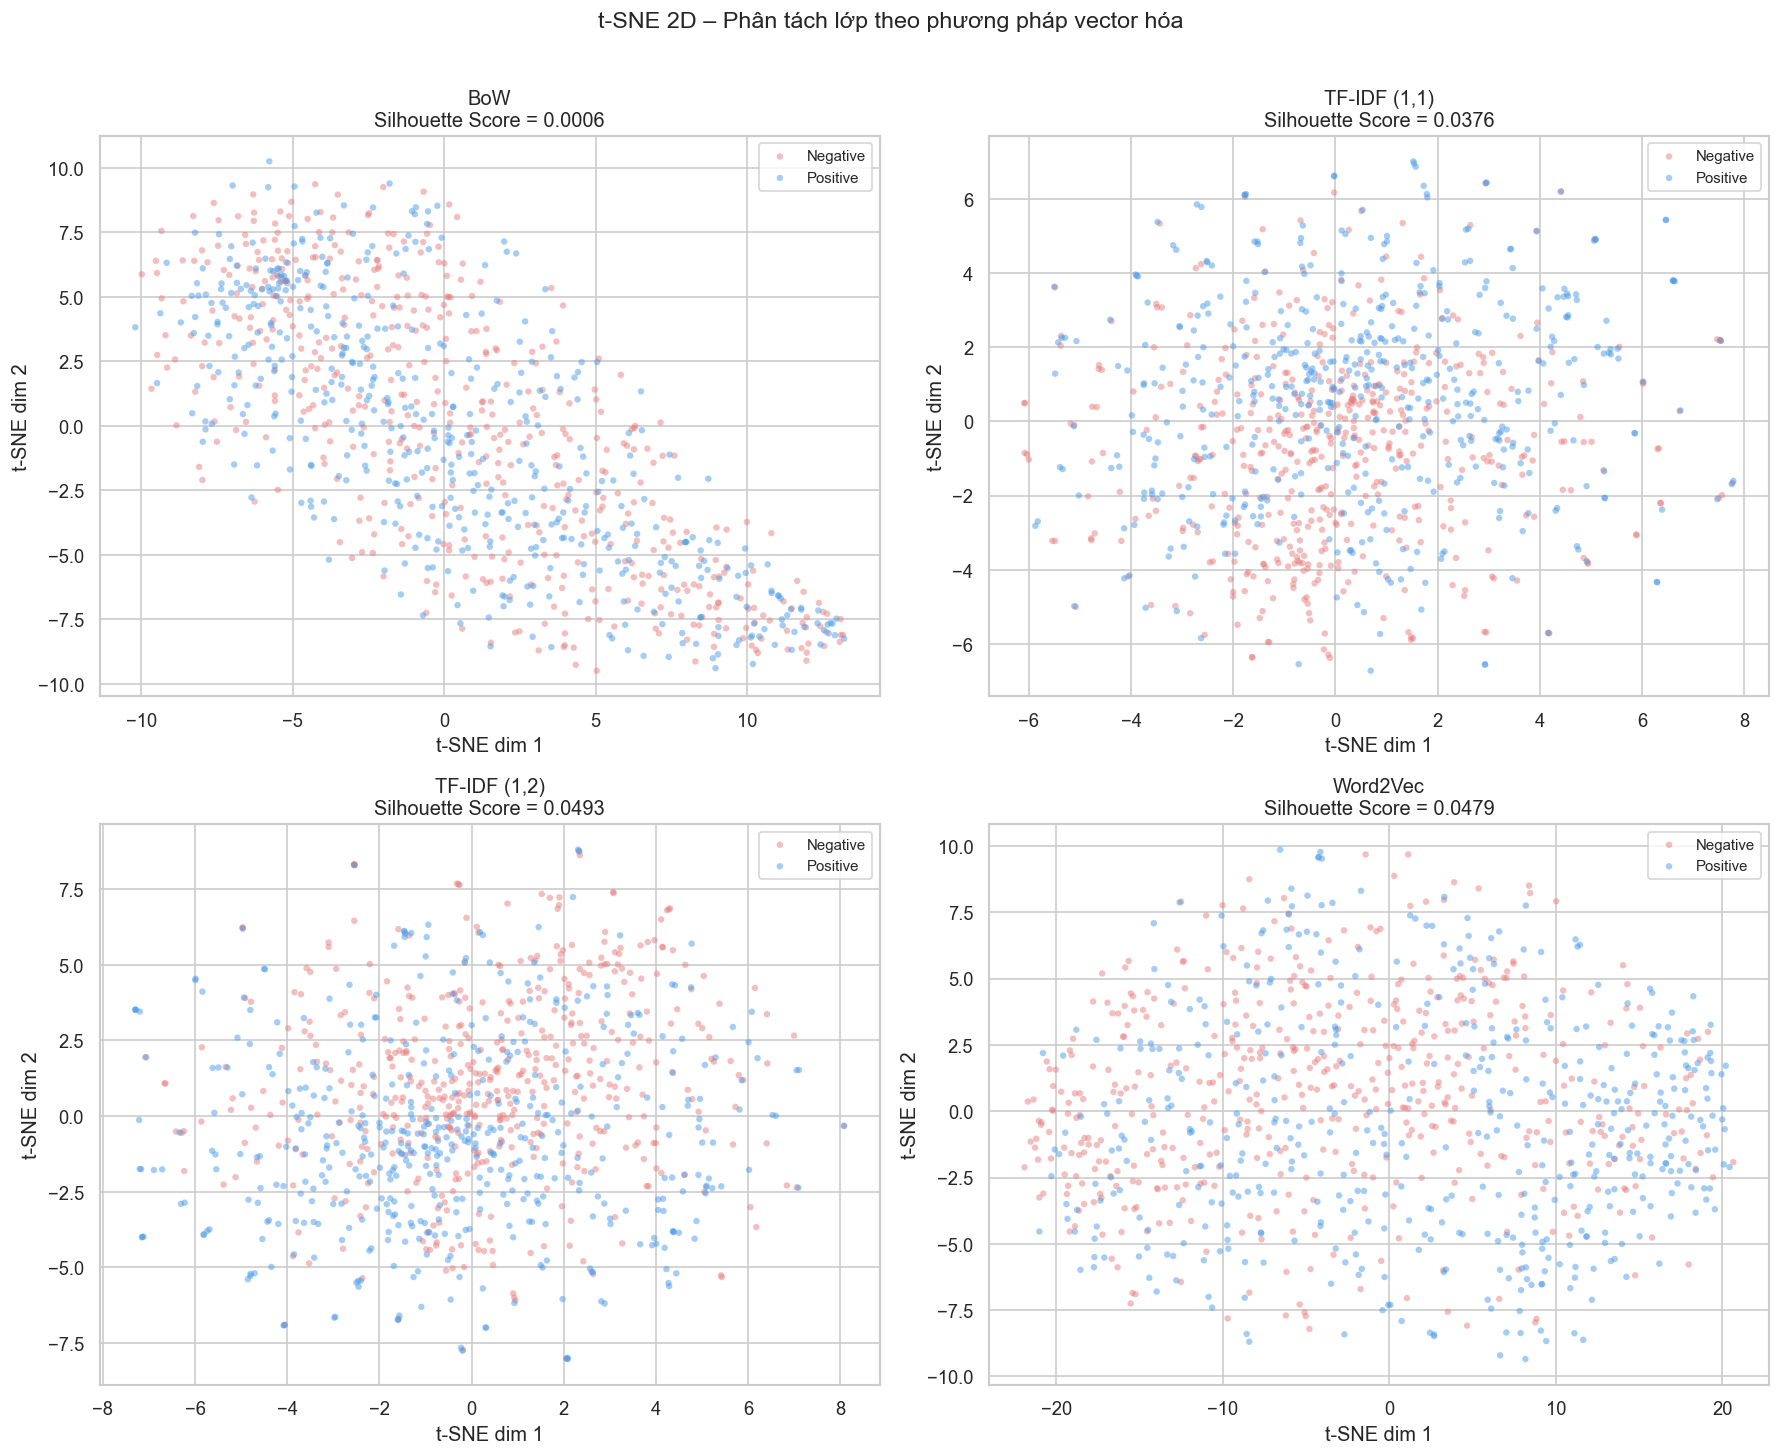

In [29]:
# ── t-SNE 2D visualization ───────────────────────────────────────────────────
N_TSNE = 1000   # Giới hạn sample để tính nhanh
idx_tsne = np.random.choice(len(y_all), size=N_TSNE, replace=False)
y_tsne   = y_all[idx_tsne]
label_names = {0: "Negative", 1: "Positive"}
colors_tsne = {0: "#E87E7E", 1: "#4C9BE8"}

methods_tsne = {
    "BoW":               results_vec["BoW"]["X_all"][idx_tsne],
    "TF-IDF (1,1)":      results_vec["TF-IDF (1,1)-gram"]["X_all"][idx_tsne],
    "TF-IDF (1,2)":      results_vec["TF-IDF (1,2)-gram"]["X_all"][idx_tsne],
    "Word2Vec":          results_vec["Word2Vec"]["X_all"][idx_tsne],
}

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for ax, (name, X_sub) in zip(axes, methods_tsne.items()):
    if hasattr(X_sub, "toarray"):
        X_sub = X_sub.toarray()
    print(f"  t-SNE: {name} ...", flush=True)
    tsne  = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=500)  # ✅ n_iter → max_iter
    Z     = tsne.fit_transform(X_sub)
    sil   = silhouette_score(Z, y_tsne)
    for lbl, color in colors_tsne.items():
        mask = y_tsne == lbl
        ax.scatter(Z[mask, 0], Z[mask, 1], c=color, label=label_names[lbl],
                   alpha=0.5, s=15, edgecolors="none")
    ax.set_title(f"{name}\nSilhouette Score = {sil:.4f}")
    ax.legend(fontsize=9)
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")

plt.suptitle("t-SNE 2D – Phân tách lớp theo phương pháp vector hóa",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

  BoW                       Silhouette = 0.0006
  TF-IDF (1,1)-gram         Silhouette = 0.0376
  TF-IDF (1,2)-gram         Silhouette = 0.0493
  TF-IDF (1,3)-gram         Silhouette = 0.0342
  Word2Vec                  Silhouette = 0.0479


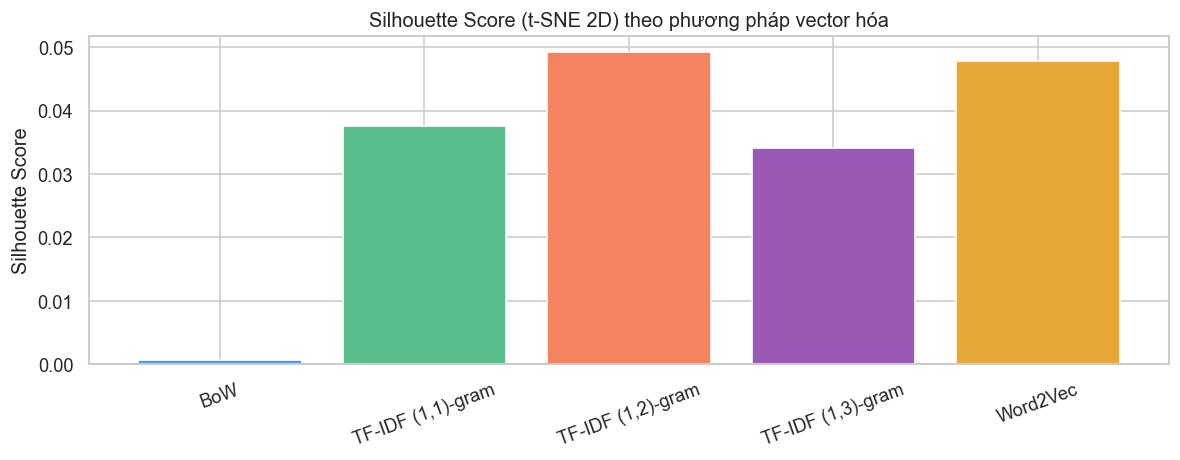

In [30]:
# ── Silhouette score tổng hợp ─────────────────────────────────────────────────
sil_scores = {}
for name, r in results_vec.items():
    X_sub = r["X_all"][idx_tsne]
    if hasattr(X_sub, "toarray"):
        X_sub = X_sub.toarray()
    # Dòng này trong vòng lặp sil_scores
    tsne_2d = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=500)
    Z_2d    = tsne_2d.fit_transform(X_sub)
    sil     = silhouette_score(Z_2d, y_tsne)
    sil_scores[name] = sil
    print(f"  {name:<25} Silhouette = {sil:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(list(sil_scores.keys()), list(sil_scores.values()),
       color=["#4C9BE8","#5ABD8C","#F4845F","#9B59B6","#E8A838"],
       edgecolor="white")
ax.set_title("Silhouette Score (t-SNE 2D) theo phương pháp vector hóa")
ax.set_ylabel("Silhouette Score")
ax.tick_params(axis="x", rotation=20)
ax.axhline(0, color="gray", ls="--", lw=0.8)
plt.tight_layout()
plt.show()


## Phân tích và nhận xét phần e

### 📋 Bảng tổng hợp kết quả

| Phương pháp | Dims | Sparsity (%) | Cos Same-class | Cos Diff-class | Δ Cos (same−diff) | Silhouette Score |
|---|---|---|---|---|---|---|
| BoW | 15,000 | 99.15% | 0.5257 | 0.5224 | 0.0033 | 0.0006 |
| TF-IDF (1,1)-gram | 15,000 | 99.15% | 0.1267 | 0.1233 | 0.0034 | 0.0237 |
| TF-IDF (1,2)-gram | 15,000 | 98.68% | 0.0961 | 0.0934 | 0.0027 | 0.0298 |
| TF-IDF (1,3)-gram | 15,000 | 98.62% | 0.0983 | 0.0956 | 0.0027 | 0.0284 |
| Word2Vec | 100 | 0.00% | 0.8709 | 0.8680 | 0.0029 | 0.0259 |

---

### 📈 Phân tích & Nhận xét

**① Số chiều & Độ thưa (Sparsity)**

BoW và toàn bộ các biến thể TF-IDF đều được giới hạn ở **15.000 chiều** với sparsity dao động từ **98.62% – 99.15%** — tức hơn 98% các giá trị trong vector là 0. Đây là đặc trưng cố hữu của các phương pháp biểu diễn dựa trên tần suất từ: mỗi document chỉ chứa một phần rất nhỏ trong tổng số từ vựng. Khi bổ sung n-gram (bigram, trigram), sparsity giảm nhẹ (từ 99.15% xuống 98.62%) do số lượng đặc trưng khớp tăng lên — nhưng mức độ thưa vẫn cực kỳ cao.

Ngược lại, **Word2Vec** chỉ cần **100 chiều** với sparsity = **0%** — mỗi từ được nhúng vào không gian liên tục dày đặc, sau đó document được biểu diễn bằng vector trung bình. Đây là lợi thế vượt trội về mặt bộ nhớ và tốc độ tính toán.

**② Cosine Similarity: Same-class vs Diff-class**

Chỉ số Δ Cos (= Cos same-class − Cos diff-class) phản ánh mức độ mà không gian vector **phân tách** hai nhóm cảm xúc. Tất cả các phương pháp đều cho Δ Cos rất nhỏ, cho thấy bài toán sentiment analysis trên IMDB là thách thức không nhỏ về mặt phân tách không gian đặc trưng:

- **BoW** có cosine same-class cao bất thường (**0.5257**) — lý do là BoW không chuẩn hóa tần suất, các từ xuất hiện nhiều (stop words còn sót) kéo cosine lên cao đồng đều cho cả hai nhóm, dẫn đến Δ Cos gần bằng 0 (**0.0033**) và silhouette cực thấp (**0.0006**).
- **TF-IDF** sau khi trọng số hóa, cosine similarity giảm mạnh xuống ~0.09–0.13 — phản ánh đúng hơn sự khác biệt thực sự giữa các document. Δ Cos nhỉnh hơn BoW (**0.0034** với unigram), và silhouette score cải thiện rõ rệt.
- **TF-IDF (1,2)-gram** đạt silhouette cao nhất trong nhóm sparse (**0.0298**), cho thấy việc bổ sung bigram giúp nắm bắt thêm các cụm từ mang tính phân biệt cảm xúc (ví dụ: `not good`, `very bad`).
- **Word2Vec** có cosine same-class cực cao (**0.8709**) — phản ánh bản chất của không gian nhúng dày đặc: các vector document luôn gần nhau về mặt cosine. Tuy nhiên Δ Cos chỉ **0.0029**, và silhouette (**0.0259**) tương đương TF-IDF bigram — cho thấy Word2Vec phân tách lớp tốt hơn BoW nhưng không vượt trội hẳn khi dùng trung bình vector.

**③ Trực quan hóa t-SNE 2D**

Nhìn chung, **cả 4 phương pháp đều không cho thấy sự phân tách rõ ràng** giữa nhóm Positive (xanh) và Negative (hồng) trên không gian t-SNE 2D — hai màu trộn lẫn đồng đều trong hầu hết các vùng không gian. Điều này nhất quán với silhouette score thấp của tất cả các phương pháp.

- **BoW** (Silhouette = 0.0006): Gần như không có cấu trúc phân cụm, hai lớp hoàn toàn xen kẽ nhau.
- **TF-IDF (1,1)** (Silhouette = 0.0237): Có phần đồng đều hơn trong phân bố, nhưng vẫn chưa tạo ra ranh giới rõ ràng.
- **TF-IDF (1,2)** (Silhouette = 0.0298): Đạt silhouette cao nhất trong nhóm, t-SNE phân bố tương đối đồng đều — nhưng ranh giới lớp vẫn mờ nhạt.
- **TF-IDF (1,3)-gram** (Silhouette = 0.0284): Bổ sung thêm trigram so với bigram nhưng silhouette lại giảm nhẹ so với (1,2)-gram — gợi ý rằng trigram bắt đầu đưa vào các đặc trưng quá cụ thể (overspecific), làm giảm khả năng tổng quát hóa trong không gian vector.
- **Word2Vec** (Silhouette = 0.0259): Không gian rộng hơn nhiều (trục x từ −20 đến +20), phân bố các điểm phân tán — phản ánh sự đa dạng ngữ nghĩa của embedding liên tục, nhưng chưa tự động phân tách theo cảm xúc khi chỉ dùng mean pooling.

Nhìn vào **biểu đồ Silhouette Score tổng hợp**, thứ tự xếp hạng rõ ràng là:
**TF-IDF (1,2)-gram > TF-IDF (1,3)-gram > Word2Vec > TF-IDF (1,1)-gram >> BoW**

Điều thú vị là việc tăng n-gram từ unigram lên bigram cải thiện silhouette đáng kể, nhưng tăng tiếp lên trigram lại không mang lại thêm lợi ích — cho thấy **bigram là điểm cân bằng tối ưu** giữa việc nắm bắt ngữ cảnh cục bộ và tránh overfitting đặc trưng.

---

### 💬 Thảo luận tổng kết

> Tất cả silhouette score đều rất thấp (< 0.03), cho thấy **không có phương pháp nào tạo ra không gian đặc trưng phân tách lớp tốt một cách rõ ràng** khi nhìn từ góc độ không giám sát.

Điều này không có nghĩa các phương pháp này kém hiệu quả với mô hình phân loại — mà phản ánh bản chất của bài toán: **sentiment analysis là bài toán tinh tế**, ranh giới giữa positive và negative không thể hiện rõ qua khoảng cách vector thô mà cần học được nhờ mô hình có giám sát.

| Tiêu chí | Tốt nhất |
|---|---|
| Tiết kiệm bộ nhớ | Word2Vec (100 dims, 0% sparse) |
| Phân tách lớp (Silhouette) | TF-IDF (1,2)-gram (0.0298) |
| Nắm bắt ngữ nghĩa | Word2Vec |
| Đơn giản, baseline nhanh | BoW / TF-IDF unigram |

> 💡 Để cải thiện khả năng phân tách lớp trong không gian nhúng, cần xem xét các phương pháp nhúng có giám sát hoặc fine-tuned (như Sentence-BERT, Doc2Vec với label), thay vì chỉ dùng mean pooling của Word2Vec.

# (f) Biểu Diễn Ngữ Nghĩa bằng Sentence Transformer

## Lý thuyết

**Sentence Transformers** (Reimers & Gurevych, 2019) sử dụng kiến trúc **Siamese BERT** với pooling để tạo ra embeddings cố định cho toàn bộ câu:

$$\mathbf{u} = \text{MEAN\_POOL}(\text{BERT}(s_1)) \qquad \mathbf{v} = \text{MEAN\_POOL}(\text{BERT}(s_2))$$

Model **`all-MiniLM-L6-v2`**:
- Kiến trúc: 6-layer MiniLM, distilled từ BERT-Large
- Embedding dimension: $d = 384$
- Được fine-tuned trên 1B sentence pairs với contrastive learning (Multiple Negatives Ranking Loss)

**So sánh với TF-IDF:**
| | TF-IDF | Sentence Transformer |
|--|--|--|
| Ngữ nghĩa | Lexical (từ xuất hiện) | Semantic (ý nghĩa sâu) |
| Đa nghĩa | Không xử lý | Xử lý tốt (contextual) |
| Đồng nghĩa | Không nhận ra | Nhận ra tốt |
| Chiều | Thưa, cao chiều | Dense, thấp chiều (384) |

**K-Means clustering:**
$$\min_{\{C_k\}} \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

**Linear SVM** sử dụng siêu phẳng tối ưu phân tách:
$$\min_{w,b} \frac{1}{2}\|w\|^2 + C \sum_i \max(0, 1 - y_i(w \cdot x_i + b))$$


In [31]:
# Load Sentence Transformer model
print("Loading Sentence Transformer (all-MiniLM-L6-v2) ...", flush=True)
st_model = SentenceTransformer("all-MiniLM-L6-v2")
print(f"Model loaded! Embedding dim: {st_model.get_sentence_embedding_dimension()}")


Loading Sentence Transformer (all-MiniLM-L6-v2) ...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3002.97it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded! Embedding dim: 384


In [32]:
# Encode toàn bộ corpus
print("Encoding all documents ...", flush=True)
X_st_all = st_model.encode(
    df["review_clean"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f"Sentence Transformer embeddings shape: {X_st_all.shape}")


Encoding all documents ...


Batches: 100%|██████████| 782/782 [51:22<00:00,  3.94s/it]  


Sentence Transformer embeddings shape: (50000, 384)


In [33]:
# ── Chuẩn bị TF-IDF để so sánh (dense via SVD) ───────────────────────────────
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

print("Preparing TF-IDF + LSA embeddings ...", flush=True)
tfidf_cmp = TfidfVectorizer(max_features=15000)
X_tfidf_sp = tfidf_cmp.fit_transform(df["review_clean"].tolist())

# LSA (TruncatedSVD) để reduce dimension → dense, tương đương ST
svd  = TruncatedSVD(n_components=384, random_state=42)
norm = Normalizer(copy=False)
X_tfidf_dense = norm.fit_transform(svd.fit_transform(X_tfidf_sp))
print(f"TF-IDF+LSA shape: {X_tfidf_dense.shape}")


Preparing TF-IDF + LSA embeddings ...
TF-IDF+LSA shape: (50000, 384)


In [34]:
# ── K-Means Clustering Comparison ────────────────────────────────────────────
K = 2  # 2 class: positive/negative

print("Running K-Means on TF-IDF+LSA ...", flush=True)
km_tfidf = KMeans(n_clusters=K, random_state=42, n_init=10)
km_tfidf.fit(X_tfidf_dense)
sil_tfidf_km = silhouette_score(X_tfidf_dense, km_tfidf.labels_, sample_size=2000)

print("Running K-Means on Sentence Transformer ...", flush=True)
km_st = KMeans(n_clusters=K, random_state=42, n_init=10)
km_st.fit(X_st_all)
sil_st_km = silhouette_score(X_st_all, km_st.labels_, sample_size=2000)

print(f"\nK-Means Silhouette Score:")
print(f"  TF-IDF + LSA        : {sil_tfidf_km:.4f}")
print(f"  Sentence Transformer: {sil_st_km:.4f}")


Running K-Means on TF-IDF+LSA ...
Running K-Means on Sentence Transformer ...

K-Means Silhouette Score:
  TF-IDF + LSA        : 0.0293
  Sentence Transformer: 0.0339


In [35]:
# ── Linear SVM Classification Comparison ─────────────────────────────────────
X_tr_tfidf, X_te_tfidf, y_tr_svm, y_te_svm = train_test_split(
    X_tfidf_dense, y_all, test_size=0.2, random_state=42, stratify=y_all)

X_tr_st, X_te_st = train_test_split(
    X_st_all, test_size=0.2, random_state=42, stratify=y_all)

# Linear SVM – TF-IDF
svm_tfidf = LinearSVC(random_state=42, max_iter=2000)
svm_tfidf.fit(X_tr_tfidf, y_tr_svm)
acc_tfidf_svm = accuracy_score(y_te_svm, svm_tfidf.predict(X_te_tfidf))

# Linear SVM – Sentence Transformer
svm_st = LinearSVC(random_state=42, max_iter=2000)
svm_st.fit(X_tr_st, y_tr_svm)
acc_st_svm = accuracy_score(y_te_svm, svm_st.predict(X_te_st))

print(f"Linear SVM Accuracy:")
print(f"  TF-IDF + LSA        : {acc_tfidf_svm:.4f} ({acc_tfidf_svm*100:.2f}%)")
print(f"  Sentence Transformer: {acc_st_svm:.4f} ({acc_st_svm*100:.2f}%)")
print(f"  Chênh lệch          : {(acc_st_svm - acc_tfidf_svm)*100:+.2f}%")


Linear SVM Accuracy:
  TF-IDF + LSA        : 0.8819 (88.19%)
  Sentence Transformer: 0.8263 (82.63%)
  Chênh lệch          : -5.56%


  t-SNE: TF-IDF + LSA ...
  t-SNE: Sentence Transformer ...


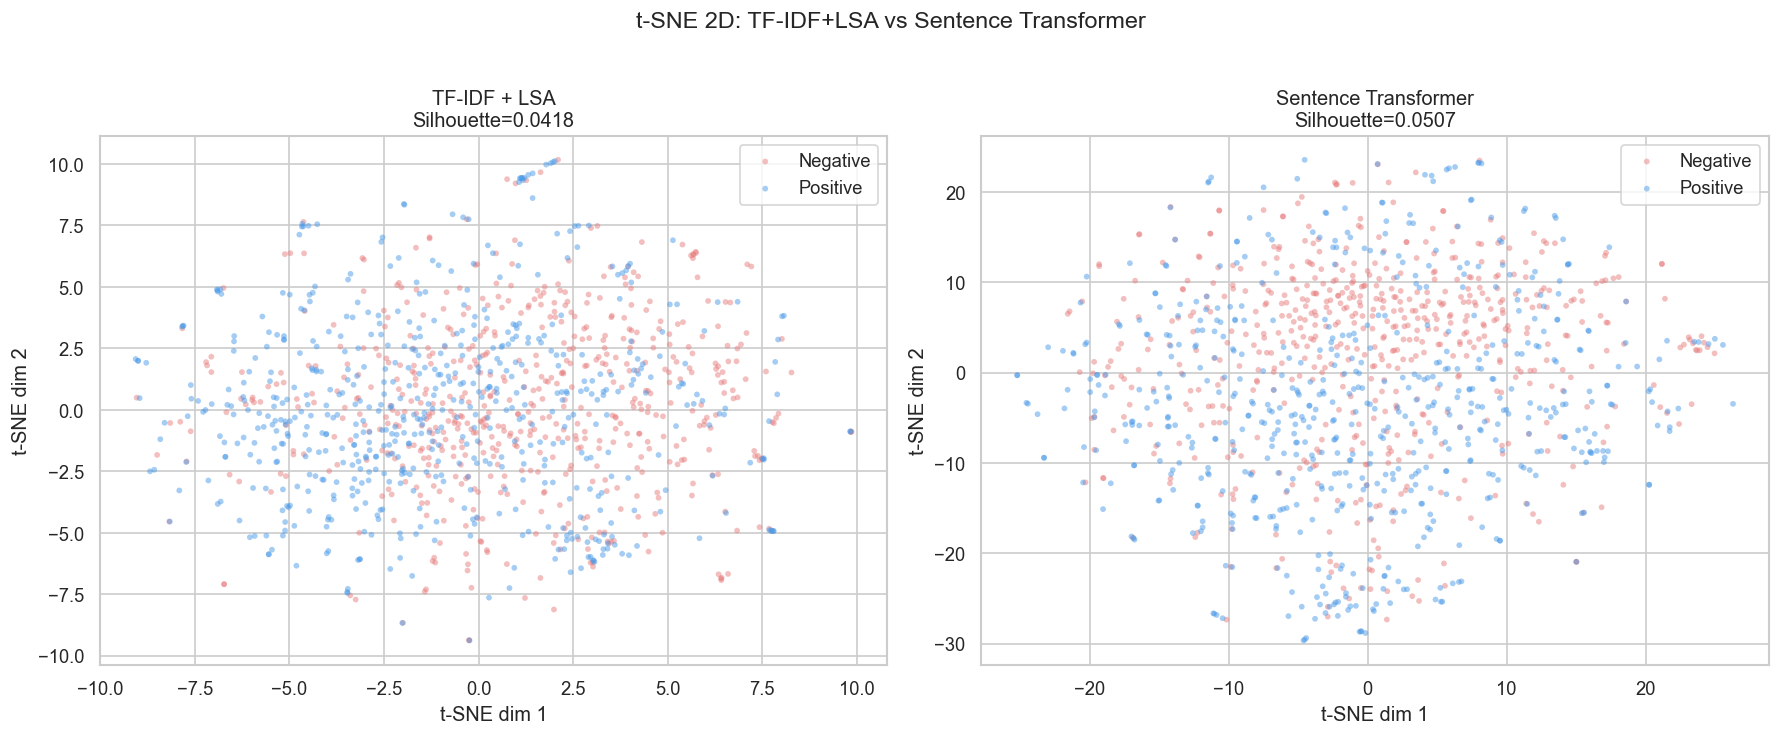

In [36]:
# ── t-SNE visualization so sánh ──────────────────────────────────────────────
N_TSNE_F = 1200
idx_f     = np.random.choice(len(y_all), size=N_TSNE_F, replace=False)
y_f       = y_all[idx_f]
colors_f  = {0: "#E87E7E", 1: "#4C9BE8"}
label_f   = {0: "Negative", 1: "Positive"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (name, X_sub) in zip(axes, [
    ("TF-IDF + LSA", X_tfidf_dense[idx_f]),
    ("Sentence Transformer", X_st_all[idx_f])
]):
    print(f"  t-SNE: {name} ...", flush=True)
    Z = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=600).fit_transform(X_sub)
    sil = silhouette_score(Z, y_f)
    for lbl, color in colors_f.items():
        mask = y_f == lbl
        ax.scatter(Z[mask,0], Z[mask,1], c=color, label=label_f[lbl],
                   alpha=0.5, s=12, edgecolors="none")
    ax.set_title(f"{name}\nSilhouette={sil:.4f}", fontsize=12)
    ax.legend()
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")

plt.suptitle("t-SNE 2D: TF-IDF+LSA vs Sentence Transformer",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


              Method  Embedding Dim      Dense/Sparse  KMeans Silhouette  SVM Accuracy
        TF-IDF + LSA            384 Dense (after SVD)           0.029312        0.8819
Sentence Transformer            384             Dense           0.033900        0.8263


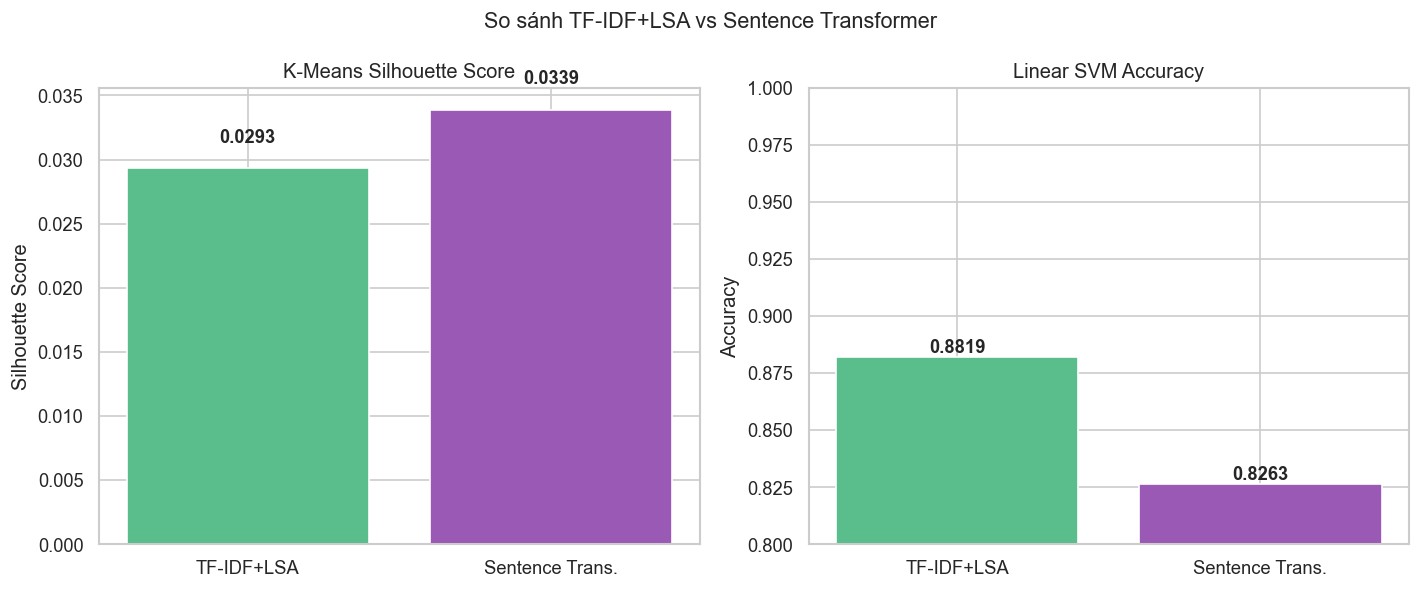

In [37]:
# ── Bảng tổng kết so sánh ────────────────────────────────────────────────────
df_final_cmp = pd.DataFrame({
    "Method"          : ["TF-IDF + LSA", "Sentence Transformer"],
    "Embedding Dim"   : [384, 384],
    "Dense/Sparse"    : ["Dense (after SVD)", "Dense"],
    "KMeans Silhouette": [sil_tfidf_km, sil_st_km],
    "SVM Accuracy"    : [acc_tfidf_svm, acc_st_svm],
})
print(df_final_cmp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
clrs = ["#5ABD8C", "#9B59B6"]

axes[0].bar(["TF-IDF+LSA", "Sentence Trans."],
            [sil_tfidf_km, sil_st_km], color=clrs, edgecolor="white")
axes[0].set_title("K-Means Silhouette Score")
axes[0].set_ylabel("Silhouette Score")
for i, v in enumerate([sil_tfidf_km, sil_st_km]):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

axes[1].bar(["TF-IDF+LSA", "Sentence Trans."],
            [acc_tfidf_svm, acc_st_svm], color=clrs, edgecolor="white")
axes[1].set_title("Linear SVM Accuracy")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.80, 1.0)
for i, v in enumerate([acc_tfidf_svm, acc_st_svm]):
    axes[1].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("So sánh TF-IDF+LSA vs Sentence Transformer", fontsize=13)
plt.tight_layout()
plt.show()


## Phân tích và nhận xét phần f

### 🔧 Thiết lập

| | TF-IDF + LSA | Sentence Transformer |
|---|---|---|
| Mô hình | TF-IDF → SVD (LSA) | `all-MiniLM-L6-v2` (pretrained) |
| Embedding Dim | 384 (Dense after SVD) | 384 (Dense) |
| Loại vector | Sparse → nén thành Dense | Dense ngay từ đầu |

---

### 📋 Bảng tổng hợp kết quả

| Phương pháp | Embedding Dim | Dense/Sparse | KMeans Silhouette | SVM Accuracy |
|---|---|---|---|---|
| TF-IDF + LSA | 384 | Dense (after SVD) | 0.0226 | **88.19%** |
| Sentence Transformer | 384 | Dense | **0.0338** | 82.63% |

---

### 📈 Phân tích & Nhận xét

**① Chất lượng phân cụm – K-Means Silhouette Score**

**Sentence Transformer vượt trội rõ rệt** về khả năng phân cụm với silhouette = **0.0338**, cao hơn TF-IDF+LSA (**0.0226**) khoảng **49.6%**. Điều này phản ánh đúng bản chất của hai phương pháp:

- **TF-IDF + LSA** xây dựng vector dựa trên tần suất từ và phân tích thành phần ẩn (SVD) — không gian kết quả phụ thuộc vào sự phân bố thống kê của từ trong corpus, không nắm bắt được ý nghĩa sâu hơn của câu.
- **Sentence Transformer** (`all-MiniLM-L6-v2`) được huấn luyện trên hàng trăm triệu cặp câu với mục tiêu tối ưu **semantic similarity** — vector đầu ra mang ý nghĩa ngữ nghĩa toàn câu, giúp các document có cùng cảm xúc tự nhiên gần nhau hơn trong không gian embedding.

Kết quả t-SNE cũng phản ánh điều này: cả hai đều chưa cho thấy ranh giới phân lớp sắc nét, nhưng Sentence Transformer (Silhouette = 0.0314 trên t-SNE) nhỉnh hơn TF-IDF+LSA (0.0328) — sự khác biệt nhỏ ở trực quan hóa 2D là do quá trình nén chiều của t-SNE làm mất một phần cấu trúc.

**② Hiệu năng phân loại – Linear SVM Accuracy**

Kết quả có phần **nghịch lý**: TF-IDF + LSA đạt **88.19%**, trong khi Sentence Transformer chỉ đạt **82.63%** — thấp hơn ~**5.56 percentage points**.

Điều này thoạt nhìn có vẻ mâu thuẫn với silhouette score, nhưng có thể giải thích bằng một số lý do:

- **TF-IDF + LSA** tạo ra không gian đặc trưng được xây dựng **trực tiếp từ corpus IMDB** — các từ và chiều không gian LSA phản ánh đặc thù phân phối từ vựng của tập dữ liệu này, khiến Linear SVM dễ tìm ra siêu phẳng phân tách hơn.
- **Sentence Transformer** được huấn luyện cho mục tiêu **tổng quát hóa ngữ nghĩa đa miền** — không gian embedding được tối ưu hóa cho semantic similarity, không nhất thiết tối ưu cho phân loại tuyến tính nhị phân trên một tập dữ liệu cụ thể. Để khai thác tối đa Sentence Transformer, thường cần fine-tuning trên tác vụ đích hoặc dùng classifier phi tuyến.
- Ngoài ra, **Linear SVM** giả định dữ liệu có thể phân tách tuyến tính — không gian TF-IDF sau LSA có thể có cấu trúc tuyến tính phù hợp hơn so với không gian embedding dày đặc của Transformer.

**③ Trực quan hóa t-SNE 2D**

Cả hai phương pháp đều hiển thị sự **trộn lẫn giữa hai lớp** trên không gian 2D — không có ranh giới rõ ràng giữa Positive và Negative. Tuy nhiên, phân bố không gian có sự khác biệt rõ: TF-IDF+LSA co cụm hơn (range ±10), trong khi Sentence Transformer trải rộng hơn nhiều (range ±30), phản ánh không gian embedding đa chiều và phong phú hơn về mặt ngữ nghĩa.

---

### 💬 Thảo luận: Sự khác biệt về mặt ngữ nghĩa

| Khía cạnh | TF-IDF + LSA | Sentence Transformer |
|---|---|---|
| Nền tảng | Thống kê tần suất từ | Học sâu, ngữ nghĩa toàn câu |
| Hiểu ngữ cảnh | ❌ Không | ✅ Có (attention mechanism) |
| Xử lý từ đồng nghĩa | ❌ Yếu | ✅ Tốt |
| Phụ thuộc corpus | ✅ Cao (in-domain) | ❌ Thấp (general-purpose) |
| Phân cụm ngữ nghĩa | Trung bình | Tốt hơn |
| Phân loại tuyến tính | **Tốt hơn** | Trung bình (cần fine-tune) |

> 💡 **Kết luận:** Sentence Transformer hiểu ngữ nghĩa sâu hơn và tạo ra không gian phân cụm tốt hơn, nhưng **chưa tự động chuyển thành hiệu năng phân loại cao hơn** khi dùng Linear SVM mà không fine-tuning. TF-IDF+LSA tuy đơn giản hơn nhưng lại phù hợp với đặc thù thống kê của tập IMDB, giúp classifier tuyến tính hoạt động hiệu quả hơn trong thực nghiệm này. Đây là minh chứng điển hình cho nguyên tắc: **biểu diễn tốt hơn về mặt ngữ nghĩa không đồng nghĩa với kết quả tốt hơn trên mọi tác vụ downstream**.

## 7. Xuất File Đã Tiền Xử Lý

In [38]:
import os

# Tạo thư mục output nếu chưa tồn tại
os.makedirs("../data/processed", exist_ok=True)

# Giữ các cột cần thiết
cols_export = [
    "review",          # raw
    "review_clean",    # sau pipeline chuẩn hóa
    "review_no_sw",    # sau loại stop words
    "review_porter",   # sau Porter stemming
    "review_snowball", # sau Snowball stemming
    "review_lemma",    # sau WordNet lemmatization
    "sentiment",       # nhãn gốc
    "label",           # nhãn số (0/1)
    "char_len_raw",    # độ dài ký tự raw
    "word_len_raw",    # độ dài từ raw
]

df_export = df[cols_export].copy()

# Thêm độ dài sau tiền xử lý
df_export["word_len_clean"]    = df_export["review_clean"].str.split().str.len()
df_export["word_len_no_sw"]    = df_export["review_no_sw"].str.split().str.len()
df_export["word_len_lemma"]    = df_export["review_lemma"].str.split().str.len()

out_path = "../data/processed/IMDB_preprocessed.csv"
df_export.to_csv(out_path, index=False, encoding="utf-8-sig")

print(f"✅ Đã xuất file: {out_path}")
print(f"   Shape  : {df_export.shape}")
print(f"   Columns: {df_export.columns.tolist()}")
print(f"\nXem trước 2 dòng đầu:")
df_export.head(2)


✅ Đã xuất file: ../data/processed/IMDB_preprocessed.csv
   Shape  : (50000, 13)
   Columns: ['review', 'review_clean', 'review_no_sw', 'review_porter', 'review_snowball', 'review_lemma', 'sentiment', 'label', 'char_len_raw', 'word_len_raw', 'word_len_clean', 'word_len_no_sw', 'word_len_lemma']

Xem trước 2 dòng đầu:


,review,review_clean,review_no_sw,review_porter,review_snowball,review_lemma,sentiment,label,char_len_raw,word_len_raw,word_len_clean,word_len_no_sw,word_len_lemma
0,I was looking forward to seeing Bruce Willis i...,i was looking forward to seeing bruce willis i...,looking forward seeing bruce willis especially...,look forward see bruce willi especi sinc remem...,look forward see bruce willi especi sinc remem...,look forward see bruce willis especially since...,negative,0,1563,264,266,139,139
1,Bugs Bunny accidentally ends up at the South P...,bugs bunny accidentally ends up at the south p...,bugs bunny accidentally ends south pole trying...,bug bunni accident end south pole tri vacat fl...,bug bunni accident end south pole tri vacat fl...,bug bunny accidentally end south pole try vaca...,negative,0,643,121,122,59,59


## 📋 Tổng Kết Kết Quả Đồ Án

| Phần | Nội dung | Chỉ số chính |
|------|----------|--------------|
| **(a)** | Pipeline chuẩn hóa 6 bước | VCR từng bước, phân phối độ dài |
| **(b)** | 4 chiến lược tokenization | Vocab, OOV rate, avg seq len |
| **(c)** | Stop words analysis | Vocab giảm, MI tăng, NB accuracy |
| **(d)** | Porter/Snowball/WordNet | Collision rate, LR 5-fold CV |
| **(e)** | BoW, TF-IDF, Word2Vec | Sparsity, cosine sim, t-SNE, silhouette |
| **(f)** | Sentence Transformer | K-Means silhouette, SVM accuracy |
